# Аналитика маркетплейса

### Описание проекта
Маркетплейс на стадии роста. Задача — оценить «здоровье» продукта: выручка, удержание (retention), LTV, CAC, эффективность маркетинговых каналов.

В этом ноутбуке:
- расчёт продуктовых метрик (MAU, ARPU, ARPPU, конверсия)
- расчёт метрик монетизации и юнит-экономики (LTV, CAC, ROI)
- А/В-тест маркетинговой компании - бонуса на первую покупку для пользователей, привлеченных из TikTok

Выводы и рекомендации — в README.md репозитория.

## Предобработка данных

In [1]:
# Загрузим библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu

In [2]:
# Загрузим датасеты, сразу приведем данные с датами к оптимальному типу
orders = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders.csv', parse_dates=['order_date', 'order_week', 'order_month'])
campaign_costs = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_campaign_costs.csv', parse_dates=['spend_month'])
users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users.csv', parse_dates=['registration_date', 'cohort_week', 'cohort_month'])
events = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events.csv', parse_dates=['event_date', 'event_week', 'event_month'])

In [3]:
# Oзнакомимся с датасетом orders
display(orders.info())
display(orders.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  datetime64[ns]
 9   order_month    31357 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.4+ MB


None

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


In [4]:
# Проверим категориальные данные на наличие дубликатов
display(orders['category_name'].unique())

array(['Инструменты и садовый инвентарь', 'Продукты питания',
       'Женская одежда', 'Аксессуары для гаджетов', 'Одежда для спорта',
       'Декор и освещение', 'Детская одежда', 'Детские игрушки',
       'Книги и канцтовары', 'Медицинские товары',
       'Косметика и парфюмерия', 'Товары для туризма',
       'Сумки и аксессуары', 'Автотовары', 'Обувь мужская',
       'Обувь женская', 'Мужская одежда', 'Бытовая техника', 'Зоотовары',
       'Товары для кухни', 'Средства для ухода', 'Мебель для дома',
       'Спортивный инвентарь', 'Товары для новорожденных',
       'Украшения и часы'], dtype=object)

In [5]:
# Проверим датасет на наличие явных дубликатов
orders_duplicates = orders.duplicated().sum()
display(f'Выявлено {orders_duplicates} явных дубликатов')

# Проверим датасет на наличие неявных дубликатов
orders_duplicates2 = orders[['order_id', 'user_id', 'order_date']].duplicated().sum()
display(f'Выявлено {orders_duplicates2} неявных дубликатов')

'Выявлено 0 явных дубликатов'

'Выявлено 0 неявных дубликатов'

In [6]:
# Создадим дополнительный столбец с выручкой маркетплейса
orders['revenue'] = orders['total_price'] * 0.05

display(orders.info())
display(orders.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  datetime64[ns]
 9   order_month    31357 non-null  datetime64[ns]
 10  revenue        31357 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(3), object(2)
memory usage: 2.6+ MB


None

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,revenue
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,553.9130
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,567.0190
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,1089.2090
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01,553.9130
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01,104.9795


In [7]:
# Изучим данные, проверим на наличие подозрительных значений
user_count = orders['user_id'].nunique()
order_count = orders['order_id'].nunique()
order_date_min = orders['order_date'].min()
order_date_max = orders['order_date'].max()
product_name_count = orders['product_name'].nunique()
product_category_count = orders['category_name'].nunique()
quantity_min = orders['quantity'].min()
quantity_max = orders['quantity'].max()
quantity_avg = orders['quantity'].mean()
unit_price_min = orders['unit_price'].min()
unit_price_max = orders['unit_price'].max()
unit_price_avg = orders['unit_price'].mean()
total_price_min = orders['total_price'].min()
total_price_max = orders['total_price'].max()
total_price_avg = orders['total_price'].mean()

display(f"Кол-во уникальных пользователей, совершивших заказы: {user_count}")
display(f"Кол-во уникальных заказов: {order_count}")
display(f"Дата и время совершения первого заказа: {order_date_min}")
display(f"Дата и время совершения последнего заказа: {order_date_max}")
display(f"Всего уникальных наименований заказанных товаров: {product_name_count}")
display(f"Всего уникальных категорий заказанных товаров: {product_category_count}")
display(f"Минимальное количество одного товара, купленного пользователем в одном заказе: {quantity_min}")
display(f"Максимальное количество одного товара, купленного пользователем в одном заказе: {quantity_max}")
display(f"Среднее количество одного товара, купленного пользователем в одном заказе: {quantity_avg.round(2)}")
display(f"Минимальная стоимость одного товара: {unit_price_min}")
display(f"Максимальная стоимость одного товара: {unit_price_max}")
display(f"Средняя стоимость одного товара: {unit_price_avg.round(2)}")
display(f"Минимальная cумма заказа: {total_price_min}")
display(f"Максимальная сумма заказа: {total_price_max}")
display(f"Средняя сумма одного заказа: {total_price_avg.round(2)}")

'Кол-во уникальных пользователей, совершивших заказы: 8922'

'Кол-во уникальных заказов: 31357'

'Дата и время совершения первого заказа: 2024-01-01 08:03:45'

'Дата и время совершения последнего заказа: 2024-12-31 23:00:53'

'Всего уникальных наименований заказанных товаров: 200'

...

'Максимальная стоимость одного товара: 63932.38'

'Средняя стоимость одного товара: 6986.91'

'Минимальная cумма заказа: 339.0'

'Максимальная сумма заказа: 191797.14'

'Средняя сумма одного заказа: 14030.18'

In [8]:
# Oзнакомимся с датасетом campaign_costs
display(campaign_costs.info())
display(campaign_costs.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   88 non-null     int64         
 1   acq_channel  88 non-null     object        
 2   spend_month  88 non-null     datetime64[ns]
 3   budget       88 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 2.9+ KB


None

,Unnamed: 0,acq_channel,spend_month,budget
0,0,Affiliate,2024-01-01,179343.3875
1,1,Affiliate,2024-02-01,175488.4875
2,2,Affiliate,2024-03-01,164543.4750
3,3,Affiliate,2024-04-01,186869.9750
4,4,Affiliate,2024-05-01,166443.7750


In [9]:
# Удалим пустой столбец
campaign_costs = campaign_costs.drop('Unnamed: 0', axis=1)

display(campaign_costs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   acq_channel  88 non-null     object        
 1   spend_month  88 non-null     datetime64[ns]
 2   budget       88 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 2.2+ KB


None

In [10]:
# Проверим категориальные данные на наличие дубликатов
display(campaign_costs['acq_channel'].unique())

array(['Affiliate', 'Direct', 'Email Marketing', 'Social Media',
       'Google Ads', 'SEO', 'TikTok'], dtype=object)

In [11]:
# Проверим датасет на наличие явных дубликатов
campaign_costs_duplicates = orders.duplicated().sum()
display(f'Выявлено {campaign_costs_duplicates} явных дубликатов')

# Проверим датасет на наличие неявных дубликатов
campaign_costs_duplicates2 = campaign_costs[['acq_channel', 'spend_month']].duplicated().sum()
display(f'Выявлено {campaign_costs_duplicates2} неявных дубликатов')

'Выявлено 0 явных дубликатов'

'Выявлено 0 неявных дубликатов'

In [12]:
# Изучим данные, проверим на наличие подозрительных значений
channel_count = campaign_costs['acq_channel'].nunique()
spend_month_min = campaign_costs['spend_month'].min()
spend_month_max = campaign_costs['spend_month'].max()
budget_min = campaign_costs['budget'].min()
budget_max = campaign_costs['budget'].max()
budget_avg = campaign_costs['budget'].mean()

display(f"Кол-во уникальных каналов привлечения: {channel_count}")
display(f"Первый месяц покупки рекламы: {spend_month_min}")
display(f"Последний месяц покупки рекламы: {spend_month_max}")
display(f"Минимальная сумма, потраченная на рекламу на один канал за один месяц: {budget_min}")
display(f"Максимальная сумма, потраченная на рекламу на один канал за один месяц: {budget_max}")
display(f"Средняя сумма, потраченная на рекламу на один канал за один месяц: {budget_avg.round(2)}")

'Кол-во уникальных каналов привлечения: 7'

'Первый месяц покупки рекламы: 2024-01-01 00:00:00'

'Последний месяц покупки рекламы: 2025-01-01 00:00:00'

'Минимальная сумма, потраченная на рекламу на один канал за один месяц: 6674.10125'

'Максимальная сумма, потраченная на рекламу на один канал за один месяц: 1533683.375'

'Средняя сумма, потраченная на рекламу на один канал за один месяц: 219626.91'

In [13]:
# Oзнакомимся с датасетом users
display(users.info())
display(users.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 3.0+ MB


None

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01


In [14]:
# Проверим категориальные данные на наличие дубликатов
display(users['gender'].unique())
display(users['region'].unique())
display(users['acq_channel'].unique())
display(users['buyer_segment'].unique())

array(['M', 'F'], dtype=object)

array(['Москва', 'Санкт-Петербург', 'Краснодар', 'Другие регионы',
       'Нижний Новгород', 'Екатеринбург', 'Московская область',
       'Новосибирск', 'Ростов-на-Дону'], dtype=object)

array(['Google Ads', 'Email Marketing', 'Affiliate', 'SEO',
       'Social Media', 'TikTok'], dtype=object)

array(['regular', 'rare', 'one_time', 'medium'], dtype=object)

In [15]:
# Проверим датасет на наличие явных дубликатов
users_duplicates = users.duplicated().sum()
display(f'Выявлено {users_duplicates} явных дубликатов')

# Проверим датасет на наличие неявных дубликатов
users_duplicates2 = users[['user_id', 'registration_date']].duplicated().sum()
display(f'Выявлено {users_duplicates2} неявных дубликатов')

'Выявлено 0 явных дубликатов'

'Выявлено 0 неявных дубликатов'

In [16]:
# Изучим данные, проверим на наличие подозрительных значений
user_count = users['user_id'].nunique()
acq_channel_count = users['acq_channel'].nunique()
region_count = users['region'].nunique()
reg_date_min = users['registration_date'].min()
reg_date_max = users['registration_date'].max()
age_min = users['age'].min()
age_max = users['age'].max()
age_avg = users['age'].mean()

display(f"Кол-во уникальных пользователей в базе: {user_count}")
display(f"Кол-во уникальных каналов привлечения: {acq_channel_count}")
display(f"Кол-во уникальных регионов: {region_count}")
display(f"Дата и время первой регистрации: {reg_date_min}")
display(f"Дата и время последней регистрации: {reg_date_max}")
display(f"Минимальный возраст покупателя: {age_min}")
display(f"Максимальный возраст покупателя: {age_max}")
display(f"Средний возраст покупателя: {age_avg.round(2)}")

'Кол-во уникальных пользователей в базе: 44151'

'Кол-во уникальных каналов привлечения: 6'

'Кол-во уникальных регионов: 9'

'Дата и время первой регистрации: 2024-01-01 00:07:00'

'Дата и время последней регистрации: 2024-12-31 23:44:00'

'Минимальный возраст покупателя: 18'

'Максимальный возраст покупателя: 70'

'Средний возраст покупателя: 43.99'

In [17]:
# Oзнакомимся с датасетом events
display(events.info())
display(events.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      785859 non-null  int64         
 1   user_id       785859 non-null  int64         
 2   event_date    785859 non-null  datetime64[ns]
 3   event_type    785859 non-null  object        
 4   os            785859 non-null  object        
 5   device        785859 non-null  object        
 6   product_name  385740 non-null  object        
 7   event_week    785859 non-null  datetime64[ns]
 8   event_month   785859 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 54.0+ MB


None

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01
5,1239,33,2024-01-01,page_view,iOS,desktop,NaN,2024-01-01,2024-01-01
6,1240,33,2024-01-01,product_view,iOS,desktop,Маска для лица,2024-01-01,2024-01-01
7,1241,33,2024-01-01,product_click,iOS,desktop,Одеяло детское,2024-01-01,2024-01-01
8,1242,33,2024-01-01,add_to_cart,iOS,desktop,Поло Ralph Lauren,2024-01-01,2024-01-01
9,1243,33,2024-01-01,checkout_start,iOS,desktop,NaN,2024-01-01,2024-01-01


In [18]:
# Проверим категориальные данные на наличие дубликатов
display(events['event_type'].unique())
display(events['os'].unique())
display(events['device'].unique())

array(['page_view', 'product_view', 'product_click', 'add_to_cart',
       'checkout_start', 'checkout_complete', 'user_logout', 'search',
       'category_view', 'filter_apply', 'promo_view', 'wishlist_add',
       'user_login', 'banner_click', 'remove_from_cart'], dtype=object)

array(['iOS', 'Windows', 'macOS', 'Android'], dtype=object)

array(['mobile', 'desktop', 'tablet'], dtype=object)

In [19]:
# Проверим датасет на наличие явных дубликатов
events_duplicates = events.duplicated().sum()
display(f'Выявлено {events_duplicates} явных дубликатов')

# Проверим датасет на наличие неявных дубликатов
events_duplicates2 = events[['event_id', 'user_id']].duplicated().sum()
display(f'Выявлено {events_duplicates2} неявных дубликатов')

'Выявлено 0 явных дубликатов'

'Выявлено 0 неявных дубликатов'

In [20]:
# Изучим данные, проверим на наличие подозрительных значений
user_count = events['user_id'].nunique()
event_count = events['event_id'].nunique()
event_date_min = events['event_date'].min()
event_date_max = events['event_date'].max()

display(f"Кол-во уникальных пользователей в базе событий: {user_count}")
display(f"Кол-во уникальных событий: {event_count}")
display(f"Дата и время первого события: {event_date_min}")
display(f"Дата и время последнего события: {event_date_max}")

'Кол-во уникальных пользователей в базе событий: 22138'

'Кол-во уникальных событий: 785859'

'Дата и время первого события: 2024-01-01 00:00:00'

'Дата и время последнего события: 2024-12-31 00:00:00'

In [21]:
# Найдем пользователя, прошедшего путь от посещения сайта до завершения заказа
# Изучим порядок шагов воронки продаж
buyer_example = events[events['user_id'] == 33]
display(buyer_example.head(6))

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
5,1239,33,2024-01-01,page_view,iOS,desktop,NaN,2024-01-01,2024-01-01
6,1240,33,2024-01-01,product_view,iOS,desktop,Маска для лица,2024-01-01,2024-01-01
7,1241,33,2024-01-01,product_click,iOS,desktop,Одеяло детское,2024-01-01,2024-01-01
8,1242,33,2024-01-01,add_to_cart,iOS,desktop,Поло Ralph Lauren,2024-01-01,2024-01-01
9,1243,33,2024-01-01,checkout_start,iOS,desktop,NaN,2024-01-01,2024-01-01
10,1244,33,2024-01-01,checkout_complete,iOS,desktop,NaN,2024-01-01,2024-01-01


## Обзор ключевых метрик

### Выручка компании (Revenue)

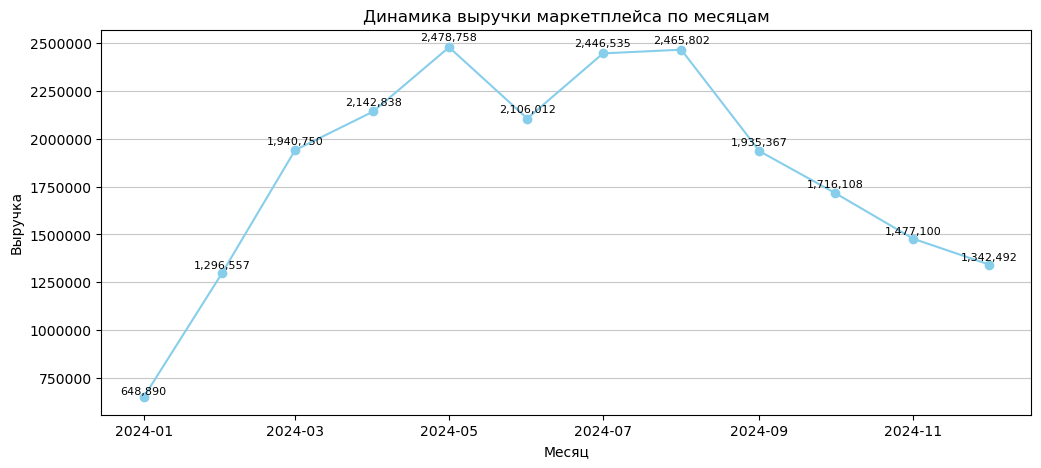

In [22]:
# Посчитаем выручку компании по месяцам
revenue = orders.groupby('order_month')['revenue'].sum().reset_index()

# Построим график
plt.figure(figsize=(12,5))
plt.plot(revenue['order_month'], revenue['revenue'], marker='o', color='skyblue')
plt.title("Динамика выручки маркетплейса по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Выручка")
plt.grid(axis='y', alpha=0.7)

# Подписываем значения
for x, y in zip(revenue['order_month'], revenue['revenue']):
    plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)
    
# Отключаем экспоненциальный формат на оси Y
plt.ticklabel_format(axis='y', style='plain')

plt.show()

Выручка маркетплейса демонстрировала уверенный рост с января по май, в мае был зафиксирован рекорд - 2,479 млн у.е. С мая по август наблюдалась стагнация показателя, выручка все также оставалась на высоком уровне (> 2,1 млн у.е.). Начиная с сентября зафиксировано резкое снижение выручки - в декабре выручка составила уже 1,342 млн у.е.

Можно предположить, что снижение выручки маркетплейса осенью и зимой обусловлены сезонностью бизнеса, однако при знакомстве с данными также были изучены наименования продаваемых товаров и их категории. Товары, продаваемые на маркетплейсе, востребованы в разное время года, поэтому сезонность спроса можно исключить.

Необходимо детально изучить влияющие на выручку метрики, чтобы найти причину ее снижения:

1. **Средняя выручка на платящего пользователя (ARPPU) и средняя выручка на пользователя (ARPU)**

* Если ARPPU снижается — падение выручки связано либо со снижением среднего чека, либо с уменьшением кол-ва заказов на одного пользователя.
* Снижение ARPU может быть обусловлено как снижением среднего чека, так и снижением кол-ва платящих пользователей.

2. **Средний чек (AOV) и количество заказов**

* Снижение среднего чека при стабильном или растущем количестве заказов говорит о смещении спроса в сторону более дешевых товаров. Это может быть следствием изменения потребительского поведения или снижения покупательной способности.

* Стабильный средний чек на фоне падения количества заказов указывает на снижение конверсии в заказ. Пользователи заходят на платформу, но не совершают покупки.

3. **Количество активных пользователей в месяц (MAU)**

Снижение MAU ведет к падению выручки.

4. **Конверсия в заказ (CR)**

Падение конверсии напрямую влияет на ARPU и общее количество заказов. Необходимо выявить возможные "узкие места": например, неудобный интерфейс, неинформативные карточки товаров, ошибки при оформлении заказа или оплате и пр.


5. **Удержание клиентов (Retention)**

Если пользователи перестают возвращаться на платформу и совершать повторные покупки, это приводит к постепенному исчерпанию активной аудитории и снижению выручки.

### ARPPU и ARPU

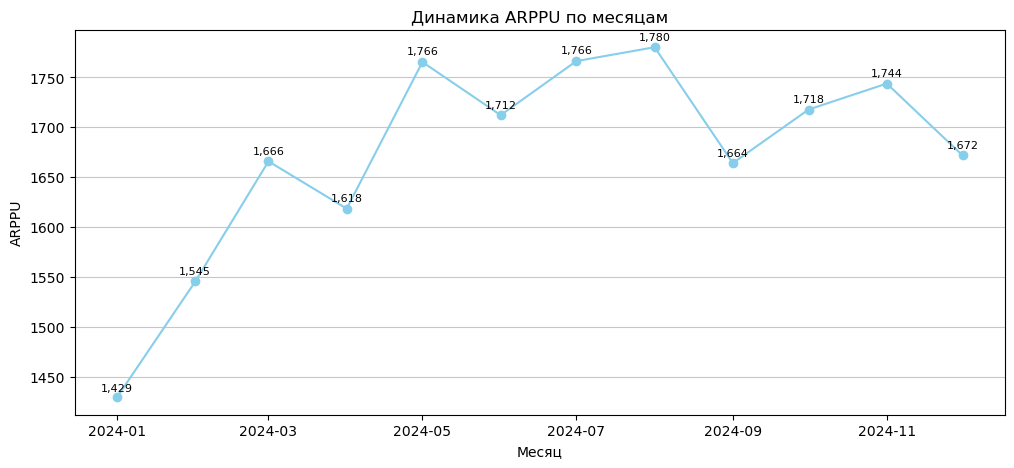

In [23]:
# Посчитаем ARPPU
# Всего платящих пользователей в месяц
monthly_users = orders.groupby('order_month')['user_id'].nunique().reset_index()

# Суммарная выручка по месяцам
monthly_revenue = orders.groupby('order_month')['revenue'].sum().reset_index()

# Объединяем таблицы и считаем ARPPU
arppu = pd.merge(monthly_users, monthly_revenue, how='inner', on='order_month')
arppu['arppu'] = round((arppu['revenue'] / arppu['user_id']), 2)

# Визуализируем
plt.figure(figsize=(12,5))
plt.plot(arppu['order_month'], arppu['arppu'], marker='o', color='skyblue')
plt.title("Динамика ARPPU по месяцам")
plt.xlabel("Месяц")
plt.ylabel("ARPPU")
plt.grid(axis='y', alpha=0.7)

# Подписываем значения
for x, y in zip(arppu['order_month'], arppu['arppu']):
    plt.text(x, y + 0.003*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.show()

Динамика средней выручки на платящего пользователя (ARPPU) демонстрирует уверенный рост с января по август (1429 – 1780 у.е.), начиная с сентября показатель стабилизировался на уровне 1660-1750 у.е. Это говорит о том, что платящие пользователи не изменили свое покупательское поведение.

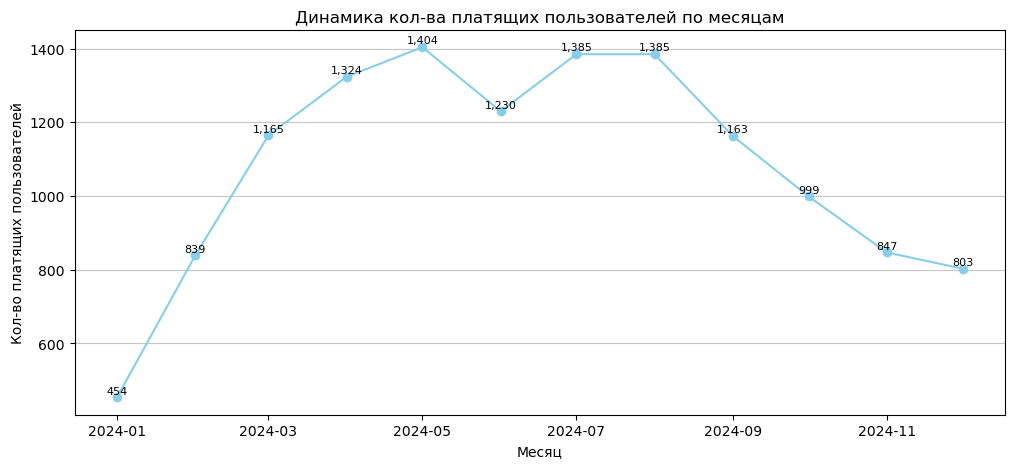

In [24]:
# Дополнительно рассмотрим динамику кол-ва платящих пользователей по месяцам
plt.figure(figsize=(12,5))
plt.plot(monthly_users['order_month'], monthly_users['user_id'], marker='o', color='skyblue')
plt.title("Динамика кол-ва платящих пользователей по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Кол-во платящих пользователей")
plt.grid(axis='y', alpha=0.7)

# Подписываем значения
for x, y in zip(monthly_users['order_month'], monthly_users['user_id']):
    plt.text(x, y + 0.003*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.show()

Начиная с сентября количество платящих пользователей начало резко снижаться: в декабре платящих пользователей стало на 42% меньше, чем в августе (803 против 1385). Отток платящей аудитории может быть результатом снижения конверсии или удержания пользователей.

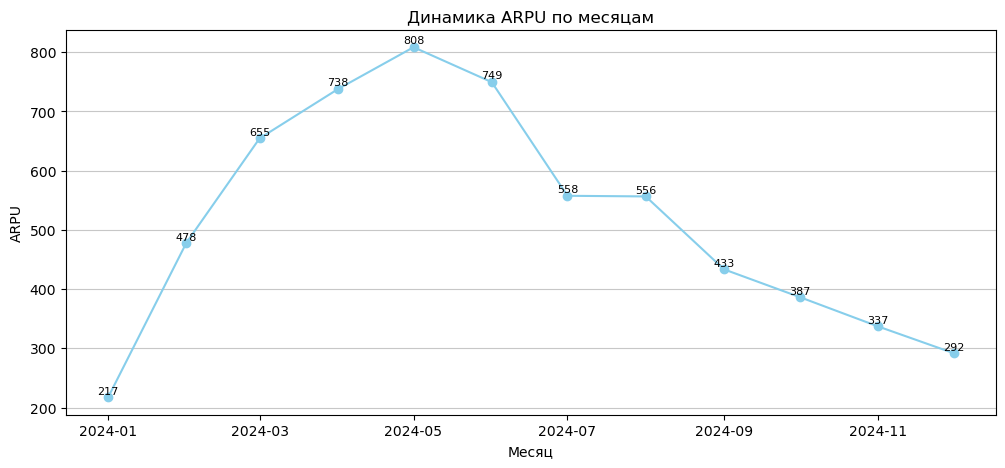

In [25]:
# Посчитаем ARPU
# Всего платящих пользователей в месяц
monthly_users_all = users.groupby('cohort_month')['user_id'].nunique().reset_index()
monthly_users_all = monthly_users_all.rename(columns={'cohort_month': 'month'})

# Суммарная выручка по месяцам
monthly_revenue = orders.groupby('order_month')['revenue'].sum().reset_index()
monthly_revenue = monthly_revenue.rename(columns={'order_month': 'month'})

# Объединяем таблицы и считаем ARPPU
arpu = pd.merge(monthly_users_all, monthly_revenue, how='inner', on='month')
arpu['arpu'] = round((arpu['revenue'] / arpu['user_id']), 2)

# Визуализируем
plt.figure(figsize=(12,5))
plt.plot(arpu['month'], arpu['arpu'], marker='o', color='skyblue')
plt.title("Динамика ARPU по месяцам")
plt.xlabel("Месяц")
plt.ylabel("ARPU")
plt.grid(axis='y', alpha=0.7)

# Подписываем значения
for x, y in zip(arpu['month'], arpu['arpu']):
    plt.text(x, y + 0.003*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.show()

Выручка с пользлователя демонстрирует негативную динамику, коррелирующую с падением выручки. Снижение ARPU фиксируется с начала июня: по сравнению с майским показателем в декабре ARPU снизился на 64%. Так как ARPPU стабилен, причиной может быть значительный приток неплатежеспособной аудитории, а также отток платящих клиентов.

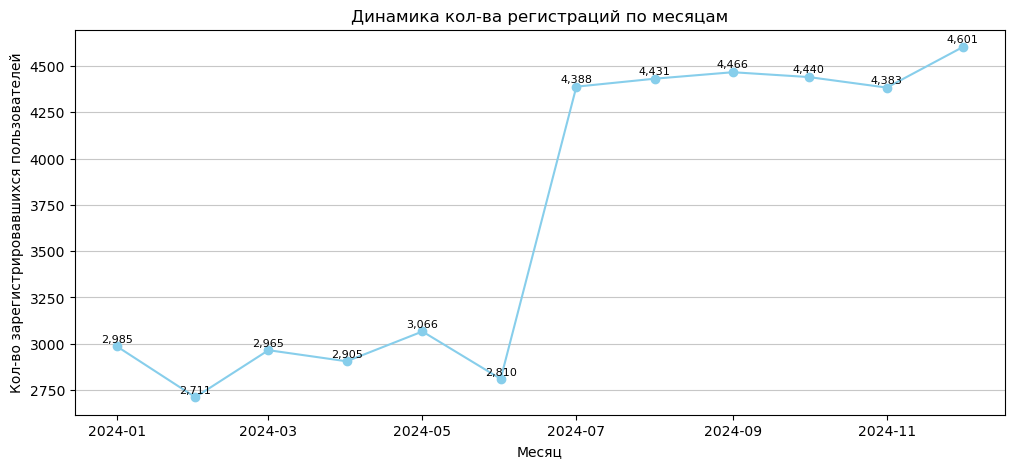

In [26]:
# Дополнительно рассмотрим динамику кол-ва регистраций по месяцам
plt.figure(figsize=(12,5))
plt.plot(monthly_users_all['month'], monthly_users_all['user_id'], marker='o', color='skyblue')
plt.title("Динамика кол-ва регистраций по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Кол-во зарегистрировавшихся пользователей")
plt.grid(axis='y', alpha=0.7)

# Подписываем значения
for x, y in zip(monthly_users_all['month'], monthly_users_all['user_id']):
    plt.text(x, y + 0.003*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.show()

Начиная с июля количество новых зарегистрированных пользователей выросло примерно в полтора раза, что объясняет причину снижения ARPU. Далеко не все пользователи, зарегистрировавшиеся на маркетплейсе, совершали покупки.

### Средний чек (AOV) и количество заказов

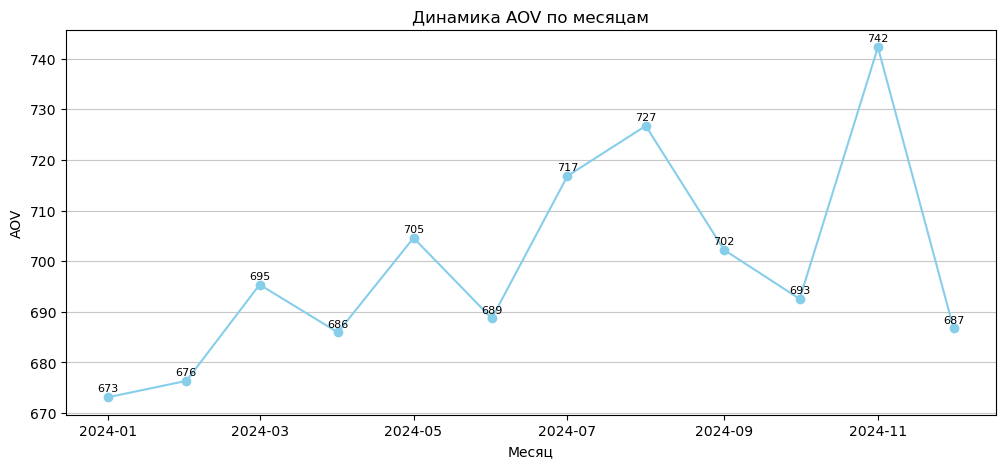

In [27]:
# Посчитаем AOV
# Суммарная стоимость всех покупок в месяц
monthly_revenue = orders.groupby('order_month')['revenue'].sum().reset_index()

# Кол-во заказов в месяц
monthly_orders = orders.groupby('order_month')['order_id'].nunique().reset_index()

# Объединяем таблицы и считаем AOV
aov = pd.merge(monthly_revenue, monthly_orders, how='inner', on='order_month')
aov['aov'] = round((aov['revenue'] / aov['order_id']), 2)

# Визуализируем
plt.figure(figsize=(12,5))
plt.plot(aov['order_month'], aov['aov'], marker='o', color='skyblue')
plt.title("Динамика AOV по месяцам")
plt.xlabel("Месяц")
plt.ylabel("AOV")
plt.grid(axis='y', alpha=0.7)

# Подписываем значения
for x, y in zip(aov['order_month'], aov['aov']):
    plt.text(x, y + 0.001*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.show()

Средний чек на протяжении года оставался стабильным, в пределах 673 - 742 у.е. Также прослеживается незначительная тенденция роста показателя. Средний чек точно не является причиной снижения выручки компании.

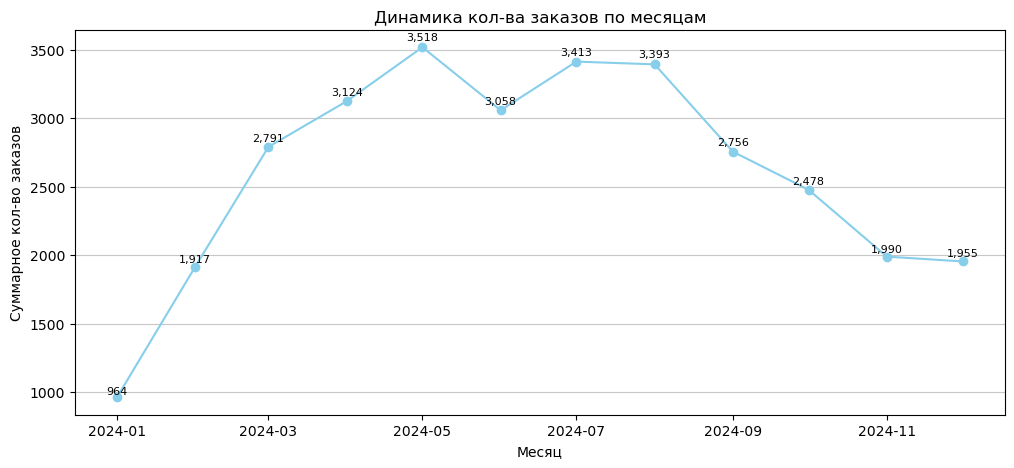

In [28]:
# Визуализируем динамику кол-ва заказов по месяцам
plt.figure(figsize=(12,5))
plt.plot(monthly_orders['order_month'], monthly_orders['order_id'], marker='o', color='skyblue')
plt.title("Динамика кол-ва заказов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Суммарное кол-во заказов")
plt.grid(axis='y', alpha=0.7)

# Подписываем значения
for x, y in zip(monthly_orders['order_month'], monthly_orders['order_id']):
    plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.show()

Начиная с сентября заметно значительное снижение количества заказов в месяц, что при стабильном среднем чеке приводит к снижению средней выручки.

### Количество активных пользователей в месяц (MAU)

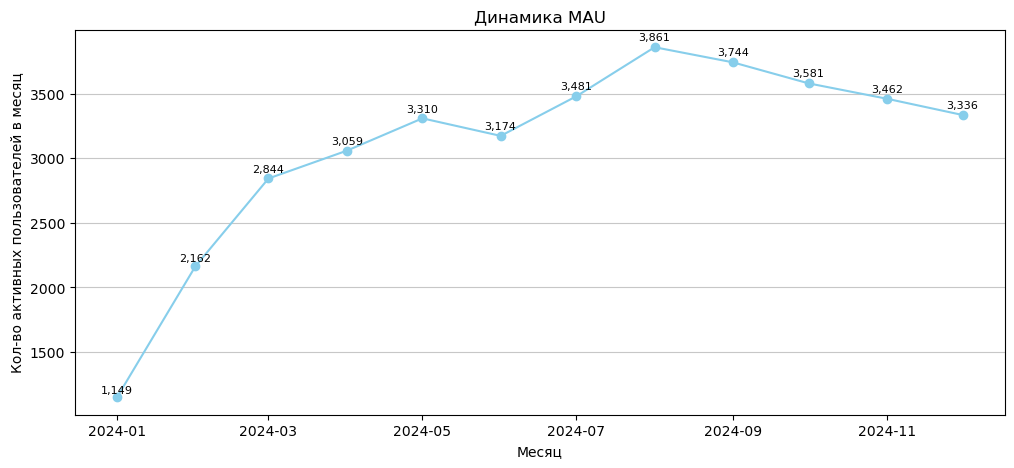

In [29]:
# Считаем MAU
mau = events.groupby('event_month')['user_id'].nunique().reset_index()

# Визуализируем
plt.figure(figsize=(12,5))
plt.plot(mau['event_month'], mau['user_id'], marker='o', color='skyblue')
plt.title("Динамика MAU")
plt.xlabel("Месяц")
plt.ylabel("Кол-во активных пользователей в месяц")
plt.grid(axis='y', alpha=0.7)

# Подписываем значения
for x, y in zip(mau['event_month'], mau['user_id']):
    plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.show()

Показатель количества активных пользователей в месяц (MAU) демонстрировал уверенный рост до августа. Начиная с сентября и до конца года фиксируется небольшое снижение MAU на 13,6%.

### Конверсия в заказ (CR)

In [30]:
# Рассчитаем кол-во зарегистрированных, активных и совершивших покупку пользователей в месяц
# Зарегистрированные пользователи
monthly_registered_users = users.groupby('cohort_month')['user_id'].nunique().reset_index()
monthly_registered_users.rename(columns={'cohort_month': 'month', 'user_id': 'registered_users'},inplace=True)
                                
# Активные пользователи
monthly_active_users = events.groupby('event_month')['user_id'].nunique().reset_index()
monthly_active_users.rename(columns={'event_month': 'month', 'user_id': 'active_users'},inplace=True)
                                
# Пользователи, совершившие покупку
monthly_paying_users = orders.groupby('order_month')['user_id'].nunique().reset_index()
monthly_paying_users.rename(columns={'order_month': 'month', 'user_id': 'paying_users'},inplace=True)

# Посчитаем конверсию из регистрации в покупку
reg_order_conv = pd.merge(monthly_registered_users, monthly_paying_users, how='left', on='month')
reg_order_conv['CR'] = round(reg_order_conv['paying_users'] / reg_order_conv['registered_users'] * 100, 2)

# Посчитаем конверсию из первой активности на платформе в покупку
active_order_conv = pd.merge(monthly_active_users, monthly_paying_users, how='left', on='month')
active_order_conv['CR'] = round(active_order_conv['paying_users'] / active_order_conv['active_users'] * 100, 2)

# Дополнительно посчитаем конверсию из регистрации в первое действие
reg_active_conv = pd.merge(monthly_registered_users, monthly_active_users, how='left', on='month')
reg_active_conv['CR'] = round(reg_active_conv['active_users'] / reg_active_conv['registered_users'] * 100, 2)

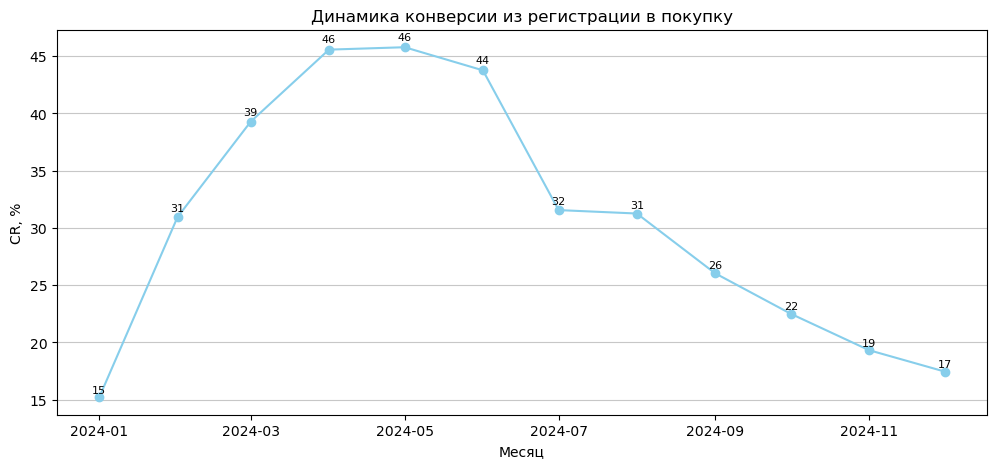

In [31]:
# Визуализируем динамику конверсии из регистрации в покупку
plt.figure(figsize=(12,5))
plt.plot(reg_order_conv['month'], reg_order_conv['CR'], marker='o', color='skyblue')
plt.title("Динамика конверсии из регистрации в покупку")
plt.xlabel("Месяц")
plt.ylabel("CR, %")
plt.grid(axis='y', alpha=0.7)

# Подписываем значения
for x, y in zip(reg_order_conv['month'], reg_order_conv['CR']):
    plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.show()

Во втором полугодии заметно снизилась конверсия из регистрации в покупку: в апреле-июне конверсия составляла в среднем 45%, а в последнем квартале ухудшилась до 19-22%. Ухудшилось качество трафика.

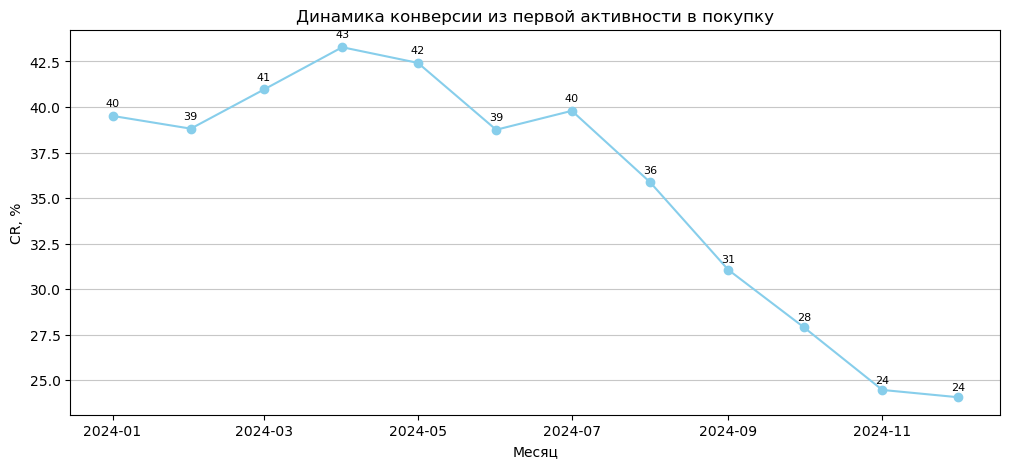

In [32]:
# Визуализируем динамику конверсии из первой активности в покупку
plt.figure(figsize=(12,5))
plt.plot(active_order_conv['month'], active_order_conv['CR'], marker='o', color='skyblue')
plt.title("Динамика конверсии из первой активности в покупку")
plt.xlabel("Месяц")
plt.ylabel("CR, %")
plt.grid(axis='y', alpha=0.7)

# Подписываем значения
for x, y in zip(active_order_conv['month'], active_order_conv['CR']):
    plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.show()

Наблюдается аналогичное снижение конверсии из первой активности на платформе в покупку (с 39-42% в первом полугодии до 24-40% во втором полугодии). Меньше активных пользователей стали совершать покупки.

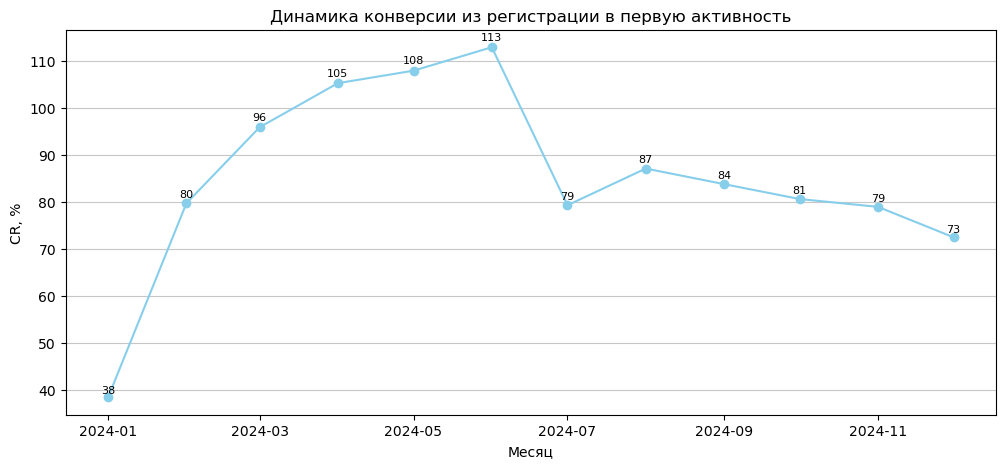

In [33]:
# Визуализируем динамику конверсии из регистрации в первую активность
plt.figure(figsize=(12,5))
plt.plot(reg_active_conv['month'], reg_active_conv['CR'], marker='o', color='skyblue')
plt.title("Динамика конверсии из регистрации в первую активность")
plt.xlabel("Месяц")
plt.ylabel("CR, %")
plt.grid(axis='y', alpha=0.7)

# Подписываем значения
for x, y in zip(reg_active_conv['month'], reg_active_conv['CR']):
    plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.show()

Конверсия из регистрации в первую активность также снизилась во втором полугодии: появилось больше неактивных пользователей, которые регистрируются, но не пользуются приложением.

### Удержание клиентов (Retention)

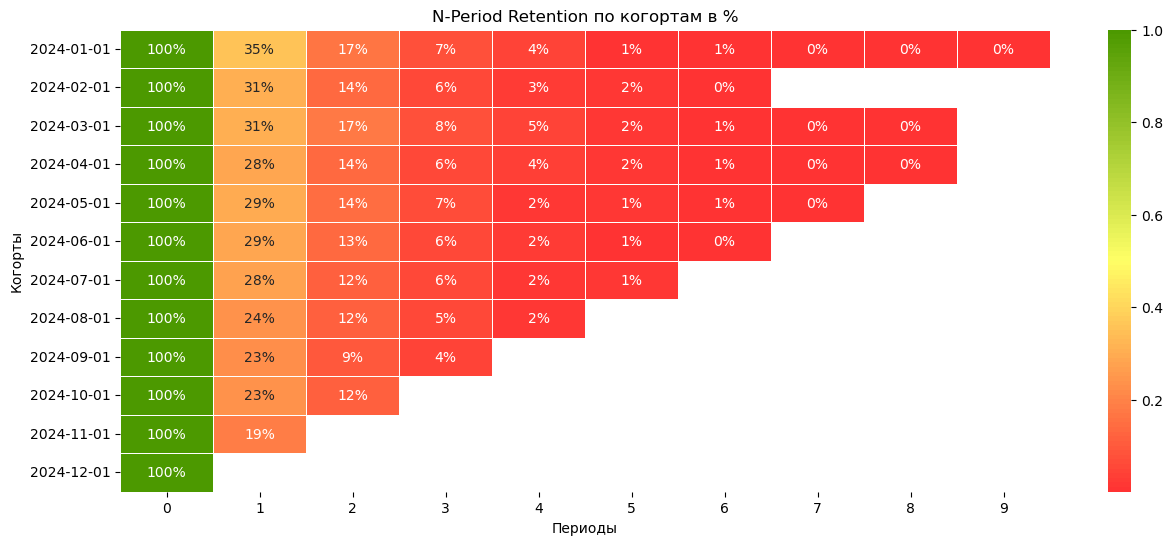

In [34]:
# Посчитаем retention rate по когортам (месяцам)

# Найдем месяц первого завершенного заказа для каждого пользователя
first_order_months = orders.groupby('user_id')['order_month'].min().reset_index()
first_order_months = first_order_months.rename(columns={'order_month': 'first_order_month'})

# Объединим с данными о месяцах совершенных заказов
retention = pd.merge(orders[['user_id', 'order_month']], first_order_months, how='left', on='user_id')

# Вычислим разницу между первым заказом пользователя и всеми последующими
retention['n_month'] = retention['order_month'].dt.to_period('M').astype('int64') - retention['first_order_month'].dt.to_period('M').astype('int64')

# Создаем сводную таблицу, возможные пропуски заменяем на нули
data_pivot = pd.pivot_table(retention,
                            values='user_id',
                            index='first_order_month',
                            columns='n_month',
                            aggfunc=pd.Series.nunique).fillna(0).astype(int)

# Каждое значение строки датафрейма делим на значение в периоде 0
data_pivot = data_pivot.div(data_pivot[0], axis=0)

# Чтобы нули не были видны на графиках, заменим их на NaN.
data_pivot[data_pivot == 0] = float('nan')

# Палитра цветов
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)

# Приводим даты к красивому виду
data_pivot.index = pd.to_datetime(data_pivot.index).strftime('%Y-%m-%d')

# Строим тепловую карту
plt.subplots(figsize=(15,6))
sns.heatmap(data_pivot,
           cmap=cmap,
           annot=True,
           fmt='.0%',
           linewidth=0.5)

plt.title('N-Period Retention по когортам в %')
plt.xlabel('Периоды')
plt.ylabel('Когорты')
plt.show()

Удержание (retention) на платформе в целом довольно низкое: уже к концу третьего месяца после совершения первого заказа остается менее 10% платящих пользователей. Во втором полугодии также заметно небольшое снижение retention.

## Оценка метрик монетизации и юнит-экономики

### Анализ LTV, CAC

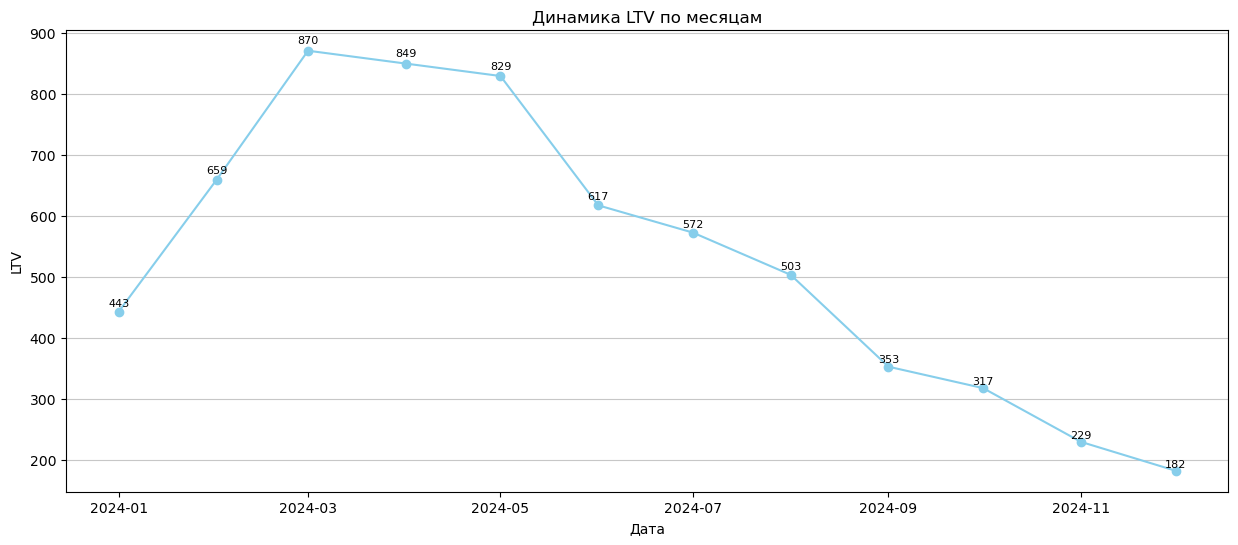

In [35]:
# Посчитаем LTV по месяцам
# Hайдем первый месяц совершения заказа и регистрации
orders['first_month'] = orders.groupby('user_id')['order_month'].transform('min')
users['first_month'] = users.groupby('user_id')['cohort_month'].transform('min')

# Посчитаем выручку по первым месяцам
monthly_revenue = orders.groupby('first_month')['revenue'].sum().reset_index()

# Посчитаем кол-во пользователей по первым месяцам
monthly_users = users.groupby('first_month')['user_id'].nunique().reset_index()

# Объединяем таблицы и считаем LTV
monthly_ltv = pd.merge(monthly_revenue, monthly_users, how='left', on='first_month')

# Cчитаем LTV 
monthly_ltv['ltv'] = monthly_ltv['revenue'] / monthly_ltv['user_id']

# Визуализируем
plt.figure(figsize=(15,6))

plt.plot(monthly_ltv['first_month'], monthly_ltv['ltv'], color='skyblue', marker='o')
for x, y in zip(monthly_ltv['first_month'], monthly_ltv['ltv']):
    plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)
plt.title("Динамика LTV по месяцам")
plt.xlabel("Дата")
plt.ylabel("LTV")
plt.grid(axis='y', alpha=0.7)
plt.show()

Зафиксировано сильное снижение LTV во втором полугодии. Это прямое следствие низкого удержания и снижения конверсии.

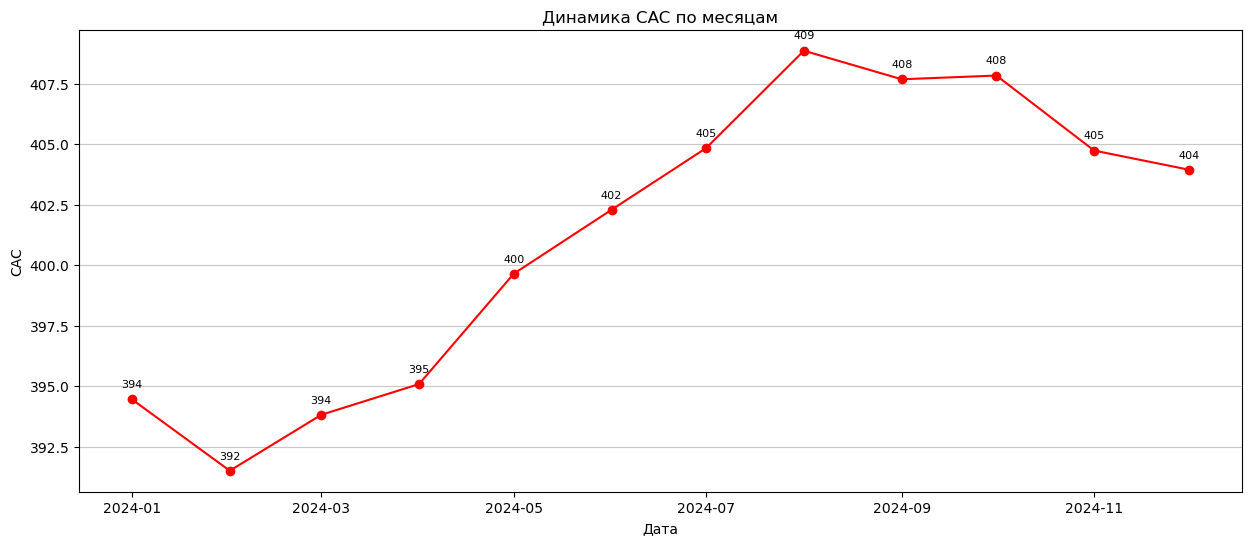

In [36]:
# Считаем САС по месяцам
monthly_campaign_costs = campaign_costs.groupby('spend_month')['budget'].sum().reset_index()
monthly_campaign_costs = monthly_campaign_costs.rename(columns={'spend_month': 'first_month'})

monthly_cac = pd.merge(monthly_users, monthly_campaign_costs, how='left', on='first_month')
monthly_cac['cac'] = monthly_cac['budget'] /  monthly_cac['user_id']

# Визуализируем
plt.figure(figsize=(15,6))

plt.plot(monthly_cac['first_month'], monthly_cac['cac'], color='red', marker='o')
for x, y in zip(monthly_cac['first_month'], monthly_cac['cac']):
    plt.text(x, y + 0.001*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)
plt.title("Динамика CAC по месяцам")
plt.xlabel("Дата")
plt.ylabel("CAC")
plt.grid(axis='y', alpha=0.7)
plt.show()

Расходы на привлечение пользователей в среднем остаются довольно стабтильными: несмотря на то, что на графике заметен рост CAC, минимальное значение САС составило 392 у.е., а максимальное - 409 у.е.

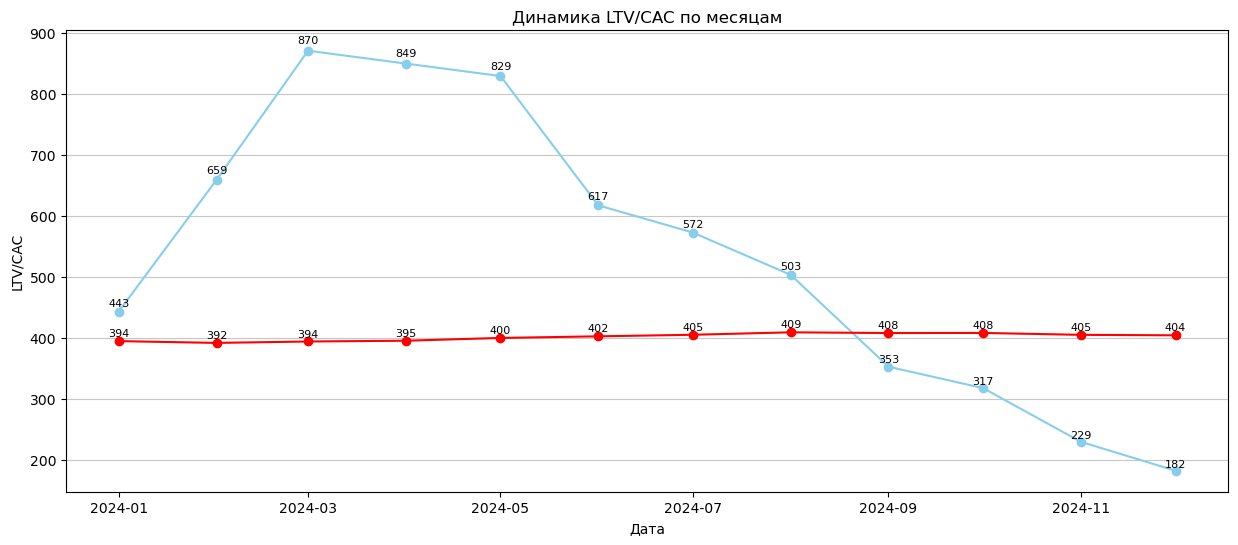

In [37]:
# Совместим графики LTV и САС
plt.figure(figsize=(15,6))

plt.plot(monthly_ltv['first_month'], monthly_ltv['ltv'], color='skyblue', marker='o')
plt.plot(monthly_cac['first_month'], monthly_cac['cac'], color='red', marker='o')
for x, y in zip(monthly_ltv['first_month'], monthly_ltv['ltv']):
    plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)
for x, y in zip(monthly_cac['first_month'], monthly_cac['cac']):
    plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)
plt.title("Динамика LTV/CAC по месяцам")
plt.xlabel("Дата")
plt.ylabel("LTV/CAC")
plt.grid(axis='y', alpha=0.7)
plt.show()

Начиная с сентября CAC стал превышать LTV, что свидетельствует о неокупаемости затрат на привлечение пользователей, пришедших в сентябре и позднее.

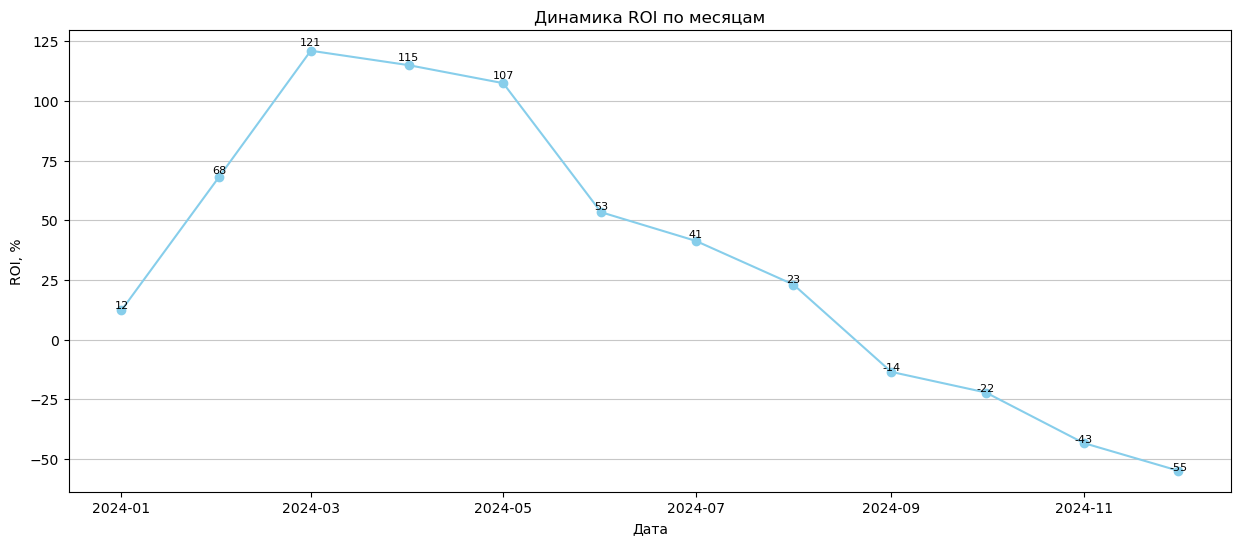

In [38]:
# Посчитаем ROI по месяцам
# Объединим таблицами с даными по LTV и CAC, считаем ROI
monthly_roi = pd.merge(monthly_ltv, monthly_cac, how='left', on='first_month')
monthly_roi['roi'] = round((monthly_roi['ltv'] - monthly_roi['cac']) / monthly_roi['cac'] * 100, 2)

# Построим график
plt.figure(figsize=(15,6))

plt.plot(monthly_roi['first_month'], monthly_roi['roi'], marker='o', color='skyblue')
for x, y in zip(monthly_roi['first_month'], monthly_roi['roi']):
    plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)
plt.title("Динамика ROI по месяцам")
plt.xlabel("Дата")
plt.ylabel("ROI, %")
plt.grid(axis='y', alpha=0.7)
plt.show()

Как уже было сказано, затраты на привлечение пользователей перестали окупаться с сентября, когда ROI достиг отрицательных значений.

,first_month,user_id,budget,cac
0,2024-01-01,2985,1.177457e+06,394.457945
1,2024-02-01,2711,1.061386e+06,391.510856
2,2024-03-01,2965,1.167680e+06,393.821373
3,2024-04-01,2905,1.147740e+06,395.091194
4,2024-05-01,3066,1.225322e+06,399.648493


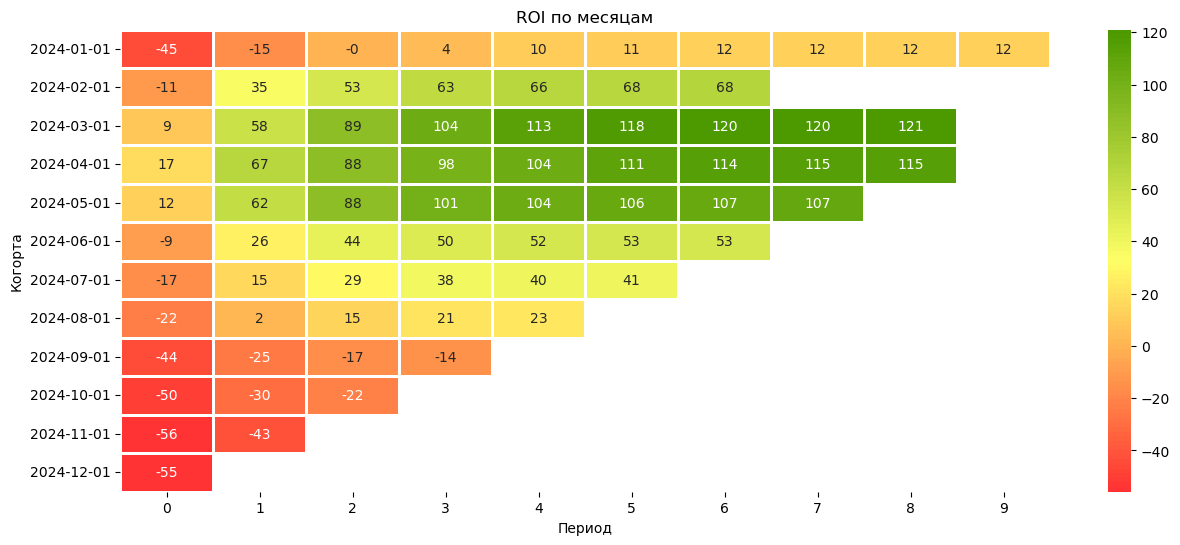

In [39]:
# Построим тепловую карту ROI по когортам (месяцам первой активности)
# Для расчета кумулятивного LTV используем таблицу orders и first_order_months. Сортируем 
orders_with_first_months = pd.merge(orders, first_order_months, how='left', on='user_id')

# Выполняем сортировку
orders_with_first_months = orders_with_first_months.sort_values('order_month')

# Вычислим разницу между первым заказом пользователя и всеми последующими
orders_with_first_months['n_month'] = orders_with_first_months['order_month'].dt.to_period('M').astype('int64') - orders_with_first_months['first_order_month'].dt.to_period('M').astype('int64')

# Считаем выручку по месяцам
ltv_cum = orders_with_first_months.groupby(['first_month','n_month'])['revenue'].sum().reset_index()
ltv_cum = ltv_cum.sort_values(['first_month','n_month'], ascending = True)

# Считаем кумулятивную выручку
ltv_cum['cum_revenue'] = ltv_cum.groupby('first_month')['revenue'].cumsum()

display(monthly_cac.head())

# Объединяем таблицы
roi = pd.merge(ltv_cum, monthly_cac, how='left', on='first_month')

# Считаем LTV и ROI
roi['ltv'] = roi['cum_revenue'] / roi['user_id']
roi['roi'] = (roi['ltv'] - roi['cac']) / roi['cac'] * 100

# Список цветов для тепловой карты и каналов, по которым необходимо провести расчеты
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)

# Строим тепловую карту:
pivot = roi.pivot(index='first_month', columns='n_month', values='roi')

# Чтобы нули не были видны на графиках, заменим их на NaN.
pivot[pivot == 0] = float('nan')

# Приводим даты к красивому виду
pivot.index = pd.to_datetime(data_pivot.index).strftime('%Y-%m-%d')
    
plt.figure(figsize=(15, 6))
sns.heatmap(pivot,
        cmap=cmap,
        annot=True,
        fmt='.0f',
        linewidths=2)
plt.title(f"ROI по месяцам")
plt.xlabel("Период")
plt.ylabel("Когорта")
plt.show()

Затраты на привлечение пользователей пришедших в сентябре и позднее, не успели окупиться из-за недостаточного времени наблюдения. Тем не менее, на графике заметно резкое снижение темпов окупаемости начиная с июня (значительное снижение roi в каждом периоде относительно более ранних когорт). Также, сентябрьская когорта и более поздние вообще перестали окупаться за данный нам период, при этом более ранние когорты (за исключением январской) окупались за 2 месяца.

## Выводы по этапам 2 и 3

Выявлено **резкое снижение выручки маркетплейса начиная с сентября** (выручка в декабре на 45,5% ниже, чем в августе).

При этом влияющие на выручку показатели продемонстрировали следующее поведение:

* **ARPPU**: уверенный рост с января по август, начиная с сентября показатель стабилизация. Это говорит о том, что платящие пользователи не изменили свое покупательское поведение.
* **ARPU**: фиксируется снижение с начала июня (-64%). Так как ARPPU стабилен, причиной может быть значительный приток неплатежеспособной аудитории, а также отток платящих клиентов.
* **AOV**: протяжении года оставался стабильным, прослеживается незначительная тенденция роста показателя.
* **Кол-во платящих пользователей**: резкое снижение (-42%) с начала сентября.
* **Кол-во зарегистрированных пользователей**: резкий рост начиная с июля (+64%), что объясняет причину снижения ARPU. Далеко не все пользователи, зарегистрировавшиеся на маркетплейсе, совершали покупки.
* **Кол-во заказов в месяц**: значительное снижение начиная с сентября (-42%), что при стабильном среднем чеке приводит к снижению средней выручки.
* **MAU**: уверенный рост до августа, начиная с сентября - небольшое снижение (-13,6%).
* **CR из регистрации в покупку**: резкое снижение во втором полугодии (-22-26 п.п.): появилось больше неактивных пользователей, которые регистрируются, но не пользуются приложением.
* **CR из первого действия в покупку**: резкое снижение во втором полугодии (до -18 п.п.). Меньше активных пользователей стали совершать покупки.
* **CR из регистрации в первое действие**:снижение во втором полугоди. Появилось больше неактивных пользователей, которые регистрируются, но не пользуются приложением.
* **Retention**: удержание на платформе в целом довольно низкое: уже к концу третьего месяца после совершения первого заказа остается менее 10% платящих пользователей. Во втором полугодии также заметно небольшое снижение retention относительно более ранних когорт.
* **LTV**: сильное снижение начиная с июня (-78%). Это прямое следствие низкого удержания и снижения конверсии.
* **CAC**: показатель относительно стабтилен: несмотря на то, что на графике заметен рост, минимальное значение САС составило 392 у.е., а максимальное - 409 у.е.
* **ROI**: Затраты на привлечение пользователей пришедших в сентябре и позднее, не успели окупиться из-за недостаточного времени наблюдения. Тем не менее, на графике заметно резкое снижение темпов окупаемости начиная с июня (значительное снижение roi в каждом периоде относительно более ранних когорт). Также, сентябрьская когорта и более поздние вообще перестали окупаться за данный нам период, при этом более ранние когорты (за исключением январской) окупались за 2 месяца.

Анализ метрик показал, что покупательская способность платящих клиентов не снизилась (стабильные ARPPU и AOV). Наиболее вероятные причины снижения выручки:
* Был привлечен большой объем незаинтересованных пользователей, которые не совершают покупки.
* Платформа теряет постоянных клиентов: Retention во втором полугодии стал хуже, чем в первом.

Для более точного выявления проблем необходимо провести дополнительные исследования:
* Затраты на привлечение: оценить объемы бюджета по рекламным каналам, оценить LTV, CAC, ROI и конверсию в разрезе каналов привлечения.
* Анализ воронки: построить и проанализировать классическую и пошаговую воронки для поиска "узких мест".
* Оценка аудитории: оценить количество пользователей, а также ARPPU по различным сегментам.

## Поиск инсайтов, точек роста и сегментация


### Анализ эффективности каналов привлечения

,acq_channel,budget,share
6,TikTok,9.695376e+06,50.2
3,Google Ads,4.663490e+06,24.1
0,Affiliate,2.012341e+06,10.4
5,Social Media,1.647396e+06,8.5
4,SEO,6.615116e+05,3.4
2,Email Marketing,5.383424e+05,2.8
1,Direct,1.087105e+05,0.6


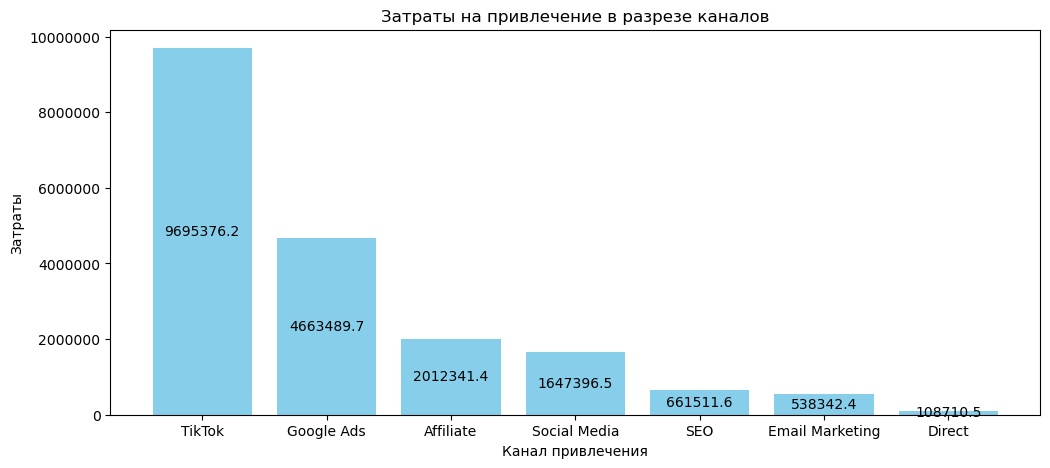

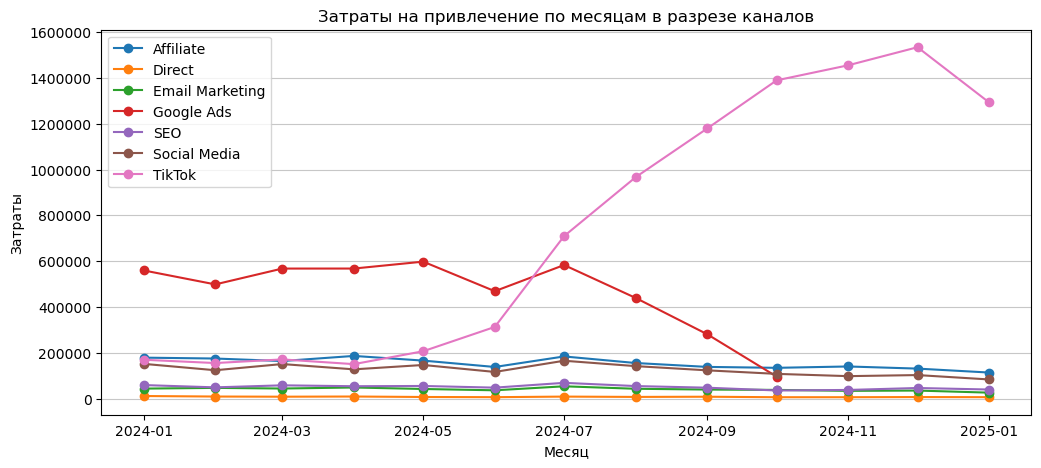

In [40]:
# Оценим объемы бюджета по каналам привлечения
exps_by_channel = campaign_costs.groupby('acq_channel')['budget'].sum().reset_index()
total_budget = exps_by_channel['budget'].sum()
exps_by_channel['share'] = (exps_by_channel['budget'] / total_budget * 100).round(1)
exps_by_channel = exps_by_channel.sort_values('share', ascending=False)
display(exps_by_channel)

monthly_exps_per_channel = campaign_costs.groupby(['spend_month', 'acq_channel'])['budget'].sum().reset_index()

plt.figure(figsize=(12,5))

barchart = plt.bar(exps_by_channel['acq_channel'], exps_by_channel['budget'], color='skyblue') 
for bar in barchart:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height/2,
             f'{height:.1f}',
             ha='center', va='center',
             fontsize=10,
             color='black')
plt.title("Затраты на привлечение в разрезе каналов")
plt.xlabel("Канал привлечения")
plt.ylabel("Затраты")
plt.ticklabel_format(axis='y', style='plain')
plt.show()

plt.figure(figsize=(12,5))

for channel in monthly_exps_per_channel['acq_channel'].unique():
    plot_df = monthly_exps_per_channel[monthly_exps_per_channel['acq_channel'] == channel]
    plt.plot(plot_df['spend_month'], plot_df['budget'], label=channel, marker='o')
plt.title("Затраты на привлечение по месяцам в разрезе каналов")
plt.xlabel("Месяц")
plt.ylabel("Затраты")
plt.ticklabel_format(axis='y', style='plain')
plt.grid(axis='y', alpha=0.7)
plt.legend()
plt.show()

Для большинства каналов суммарные затраты на привлечение за год не превысили 2 млн у.е. Большая часть бюджета ушла на каналы TikTok (9,7 млн у.е. или 50% от суммарного бюджета) и Google Ads (4,66 млн у.е. или 24% годового бюджета.

При изучении изучении помесячной динамики затрат на маркетинг выявлено следующее:
* Затраты на каналы Affiliate, Social Media, SEO, Email Marketing и Direct оставались примерно на одинаковом уровне и не превышали 200 тыс у.е./мес.
* Затраты на канал Google Ads были наиболее высокими в начале года (500-600 у.е./мес.), но начиная с августа компания урезала расходы на данный канал и уже в октябре полностью отказалась от него.
* В начале года затраты на канал TikTok не превышали 200 у.е./мес., но начиная с июня они начали сильно расти: в последнем квартале на данный канал привлечения тратилось порядка 1,3-1,55 млн у.е./мес.

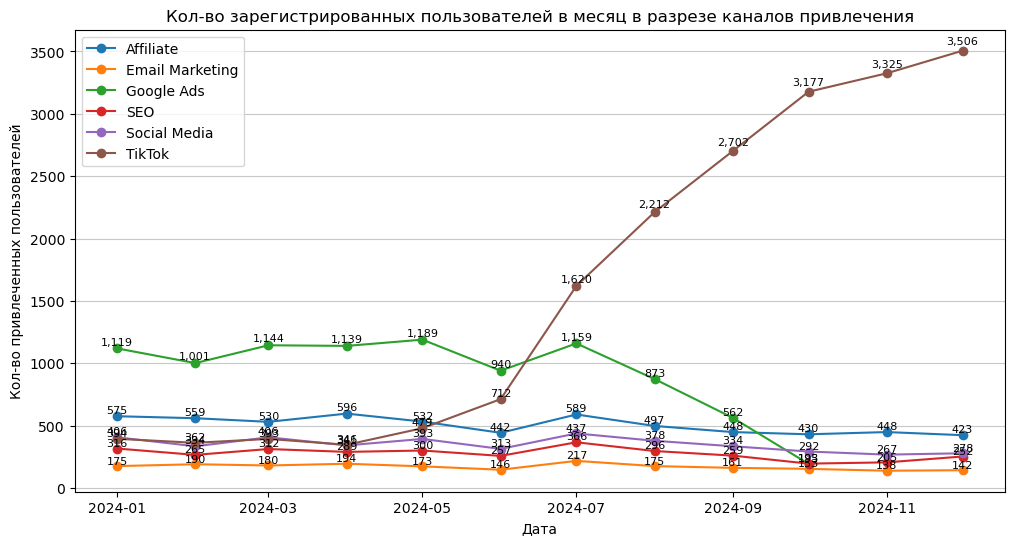

In [41]:
# Проверим причину аномалий в данных по каналу google_ads в октябре
users_regs = users.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index()

plt.figure(figsize=(12,6))

for channel in users_regs['acq_channel'].unique():
    plot_df = users_regs[users_regs['acq_channel'] == channel]
    plt.plot(plot_df['cohort_month'], plot_df['user_id'], marker='o', label=channel)
    for x, y in zip(plot_df['cohort_month'], plot_df['user_id']):
        plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)
plt.title("Кол-во зарегистрированных пользователей в месяц в разрезе каналов привлечения")
plt.xlabel("Дата")
plt.ylabel("Кол-во привлеченных пользователей")
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.show()

Выделяемый на различные каналы бюджет прямопроворционально влияет на количество новых привлеченных пользователей.

* При сокращении бюджета на канал Google Ads число привлеченных пользователей начало резко снижаться.
* При увеличиении затрат на канал TikTok количество привлеченных пользователей резко выросло с 350-400 новых пользователей в месяц до 3100-3500.
* Канал Direct, на который тратится минимальная доля бюджета (<1%), за год не привлек ни одного пользователя.

In [42]:
# Посчитаем LTV по каналам привлечения
# Присоединим к таблице orders информацию о каналах привлечения
orders = pd.merge(orders, users[['user_id', 'acq_channel']], how='left', on='user_id')

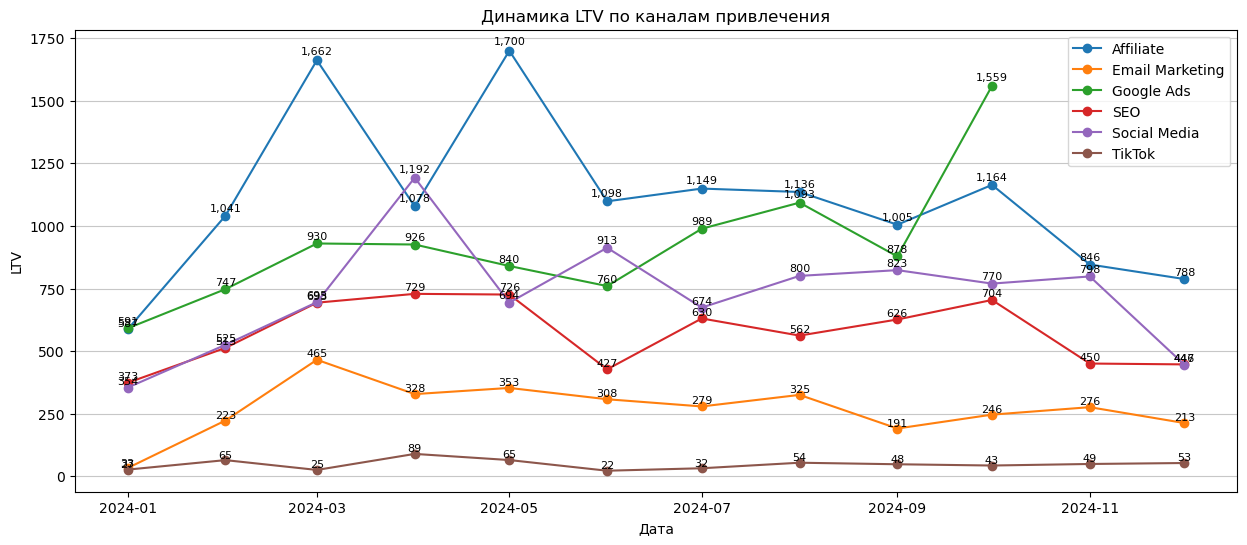

In [43]:
# Посчитаем выручку по первым месяцам
monthly_revenue = orders.groupby(['first_month', 'acq_channel'])['revenue'].sum().reset_index()

# Посчитаем кол-во пользователей по первым месяцам
monthly_users = users.groupby(['first_month', 'acq_channel'])['user_id'].nunique().reset_index()

# Объединяем таблицы и считаем LTV
channels_ltv = pd.merge(monthly_revenue, monthly_users, how='left', on=['first_month', 'acq_channel'])

# Cчитаем LTV 
channels_ltv['ltv'] = channels_ltv['revenue'] / channels_ltv['user_id']

# Визуализируем
plt.figure(figsize=(15,6))

for channel in channels_ltv['acq_channel'].unique():
    plot_df = channels_ltv[channels_ltv['acq_channel'] == channel]
    plt.plot(plot_df['first_month'], plot_df['ltv'], label=channel, marker='o')
    for x, y in zip(plot_df['first_month'], plot_df['ltv']):
        plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)
plt.title("Динамика LTV по каналам привлечения")
plt.xlabel("Дата")
plt.ylabel("LTV")
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.show()

Самых платящих пользователей приносили каналы:
* Affiliate (LTV 590-1700)
* Google Ads (LTV 590-1560)
* Social Media (LTV 370-1190)

Канал TikTok, на который было потрачено около половины годового бюджета, привлекает пользователей с экстремально низким LTV (22-89 у.е.).

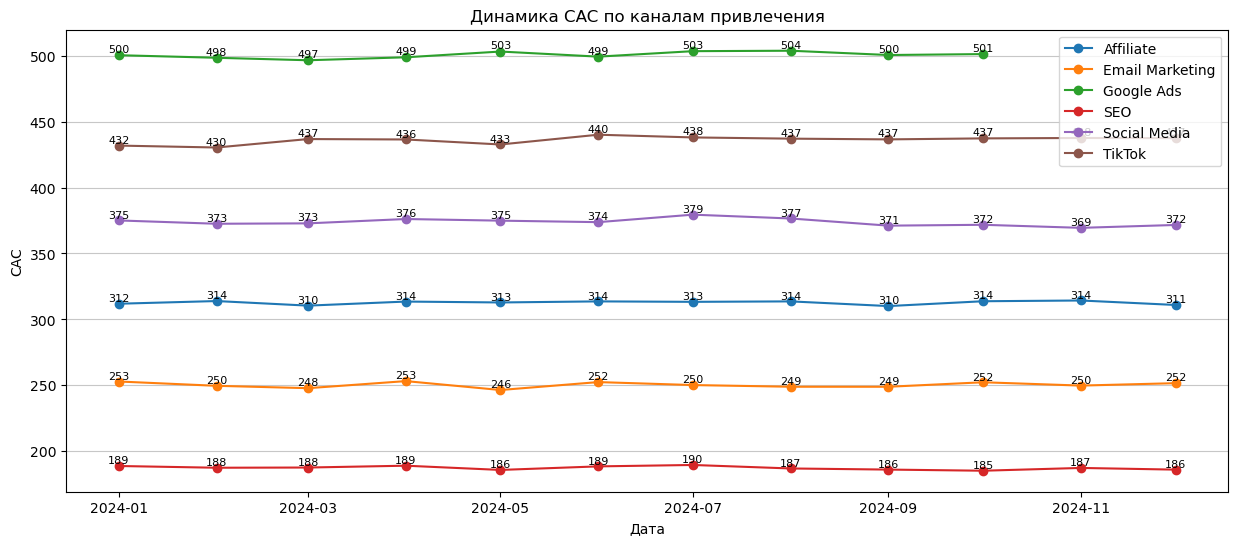

In [44]:
# Считаем САС по каналам привлечения
channels_campaign_costs = campaign_costs.groupby(['spend_month', 'acq_channel'])['budget'].sum().reset_index()
channels_campaign_costs = channels_campaign_costs.rename(columns={'spend_month': 'first_month'})


channels_cac = pd.merge(monthly_users, channels_campaign_costs, how='left', on=['first_month', 'acq_channel'])
channels_cac['cac'] = channels_cac['budget'] / channels_cac['user_id']

# Визуализируем
plt.figure(figsize=(15,6))

for channel in channels_cac['acq_channel'].unique():
    plot_df = channels_cac[channels_cac['acq_channel'] == channel]
    plt.plot(plot_df['first_month'], plot_df['cac'], label=channel, marker='o')
    for x, y in zip(plot_df['first_month'], plot_df['cac']):
        plt.text(x, y + 0.001*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)
plt.title("Динамика CAC по каналам привлечения")
plt.xlabel("Дата")
plt.ylabel("CAC")
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.show()

Наиболее дорогими каналами привлечения являются каналы Google Ads (ок. 500 у.е./мес) и TikTok (~435 у.е./мес).

Самый дешевый канал - SEO (~187 у.е./мес), при этом демонстрирующий средний LTV (370-705 у.е.)

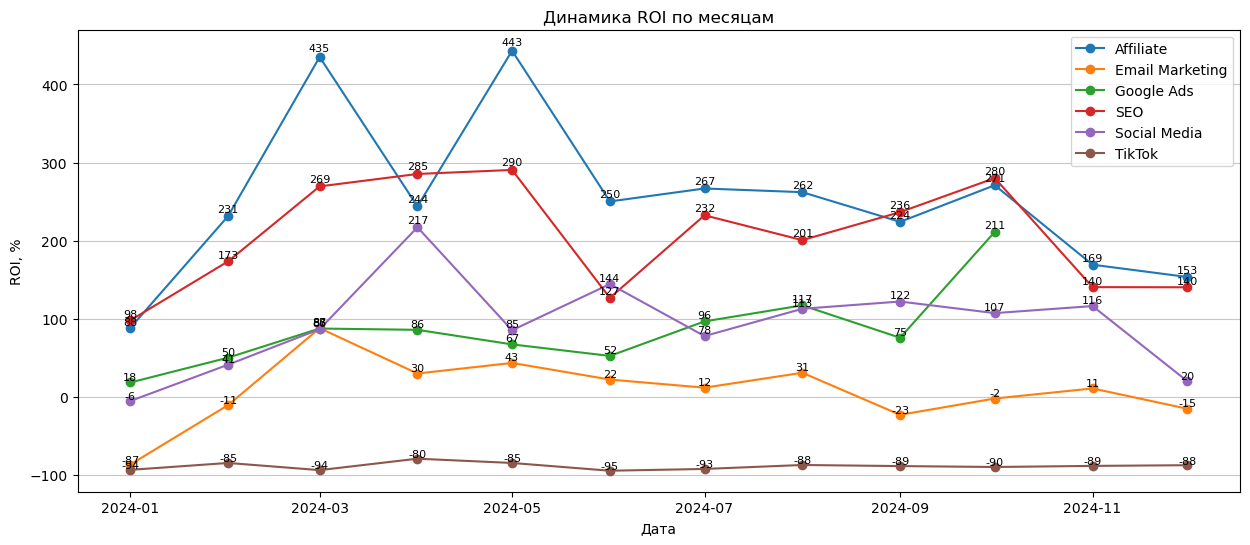

In [45]:
# Посчитаем ROI по каналам привлечения
# Объединим таблицами с даными по LTV и CAC, считаем ROI
channels_roi = pd.merge(channels_ltv, channels_cac, how='left', on=['first_month', 'acq_channel'])
channels_roi['roi'] = round((channels_roi['ltv'] - channels_roi['cac']) / channels_roi['cac'] * 100, 2)

# Построим график
plt.figure(figsize=(15,6))

for channel in channels_roi['acq_channel'].unique():
    plot_df = channels_roi[channels_roi['acq_channel'] == channel]
    plt.plot(plot_df['first_month'], plot_df['roi'], label=channel, marker='o')
    for x, y in zip(plot_df['first_month'], plot_df['roi']):
        plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)
plt.title("Динамика ROI по месяцам")
plt.xlabel("Дата")
plt.ylabel("ROI, %")
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.show()

Оценка ROI продемонстрировала следующее:
* Самые окупаемые каналы: Affiliate (в среднем ~200-250%, максимум - 443% в мае) и SEO (120-290%). Канал Affiliate демонстрирует тенденцию к снижению конверсии к концу года, однако покалатель остается самым высоким в сравнении с другими каналами.
* Каналы с самой низкой окупаемостью: TikTok (стабильно -80% и ниже на протяжении всего года) Email Marketing (-94 - +88%).
* Канал Google Ads, привлекающих пользователей с высокой платежеспособностью, каждый месяц стабильно окупался в среднем на 50-80%.

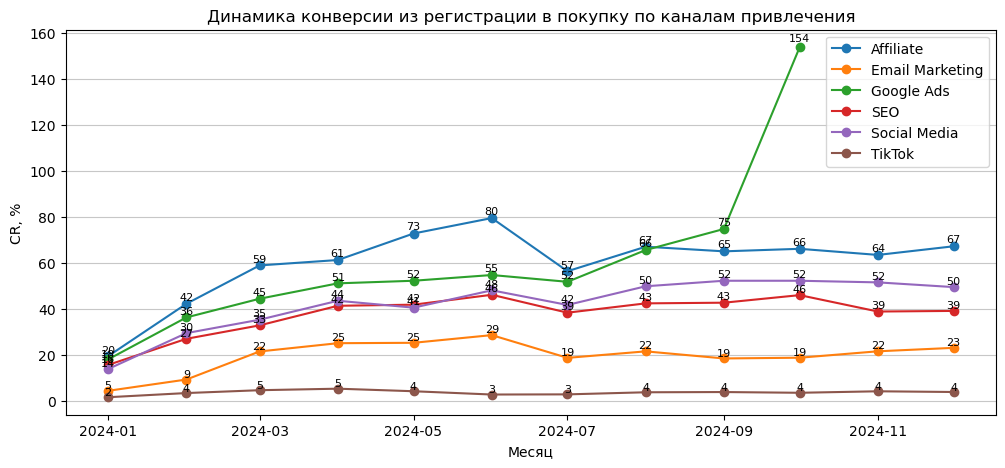

In [46]:
# Рассчитаем конверсию в разрезе каналов привлечения
# Зарегистрированные пользователи
registered_users = users.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index()
registered_users.rename(columns={'cohort_month': 'month', 'user_id': 'registered_users'},inplace=True)
                                
# Пользователи, совершившие покупку
paying_users = orders.groupby(['order_month', 'acq_channel'])['user_id'].nunique().reset_index()
paying_users.rename(columns={'order_month': 'month', 'user_id': 'paying_users'},inplace=True)

# Посчитаем конверсию из регистрации в покупку
conv = pd.merge(registered_users, paying_users, how='left', on=['month', 'acq_channel'])
conv['CR'] = round(conv['paying_users'] / conv['registered_users'] * 100, 2)

# Визуализируем
plt.figure(figsize=(12,5))

for channel in conv['acq_channel'].unique():
    plot_df = conv[conv['acq_channel'] == channel]
    plt.plot(plot_df['month'], plot_df['CR'], marker='o', label=channel)
    # Подписываем значения
    for x, y in zip(plot_df['month'], plot_df['CR']):
        plt.text(x, y + 0.01*y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)
plt.title("Динамика конверсии из регистрации в покупку по каналам привлечения")
plt.xlabel("Месяц")
plt.ylabel("CR, %")
plt.legend()
plt.grid(axis='y', alpha=0.7)

plt.show()

Анализ динамики конверсии из регистрации в покупку показывает следующее:
* Высокая конверсия: каналы Affiliate (в среднем 60-80%) и Google Ads (в среднем 40-55%).
* Средняя конверсия: каналы SEO и Social Media (в среднем 40-50%).
* Низкая конверсия: каналы Email Marketing (5-30%) и TikTok (5% и ниже).

### Анализ воронки

In [47]:
# Добавим событиe завершение оплаты
orders['event_type'] = 'payment_complete' # оплата заказа
events_full = pd.concat([orders, events], ignore_index=True)
# Создаем датасет для создания воронки
display(events_full)

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,revenue,first_month,acq_channel,event_type,event_id,event_date,os,device,event_week,event_month
0,1.0,3,2024-01-19 01:52:52,Шуруповерт,2.0,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,553.9130,2024-01-01,Google Ads,payment_complete,NaN,NaT,NaN,NaN,NaT,NaT
1,2.0,3,2024-01-19 01:52:52,Молоток слесарный,1.0,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,567.0190,2024-01-01,Google Ads,payment_complete,NaN,NaT,NaN,NaN,NaT,NaT
2,3.0,3,2024-01-19 01:52:52,Секатор садовый,2.0,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,1089.2090,2024-01-01,Google Ads,payment_complete,NaN,NaT,NaN,NaN,NaT,NaT
3,4.0,3,2024-01-25 13:59:38,Шуруповерт,2.0,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01,553.9130,2024-01-01,Google Ads,payment_complete,NaN,NaT,NaN,NaN,NaT,NaT
4,5.0,3,2024-01-25 13:59:38,Чай черный,1.0,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01,104.9795,2024-01-01,Google Ads,payment_complete,NaN,NaT,NaN,NaN,NaT,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817211,NaN,44749,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaT,NaN,checkout_complete,838155.0,2024-12-31,Android,mobile,2024-12-30,2024-12-01
817212,NaN,44749,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaT,NaN,filter_apply,838156.0,2024-12-31,Android,mobile,2024-12-30,2024-12-01
817213,NaN,44749,NaT,Лоферы лакированные,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaT,NaN,wishlist_add,838157.0,2024-12-31,Android,mobile,2024-12-30,2024-12-01
817214,NaN,41393,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaT,NaN,page_view,807643.0,2024-12-31,Windows,tablet,2024-12-30,2024-12-01


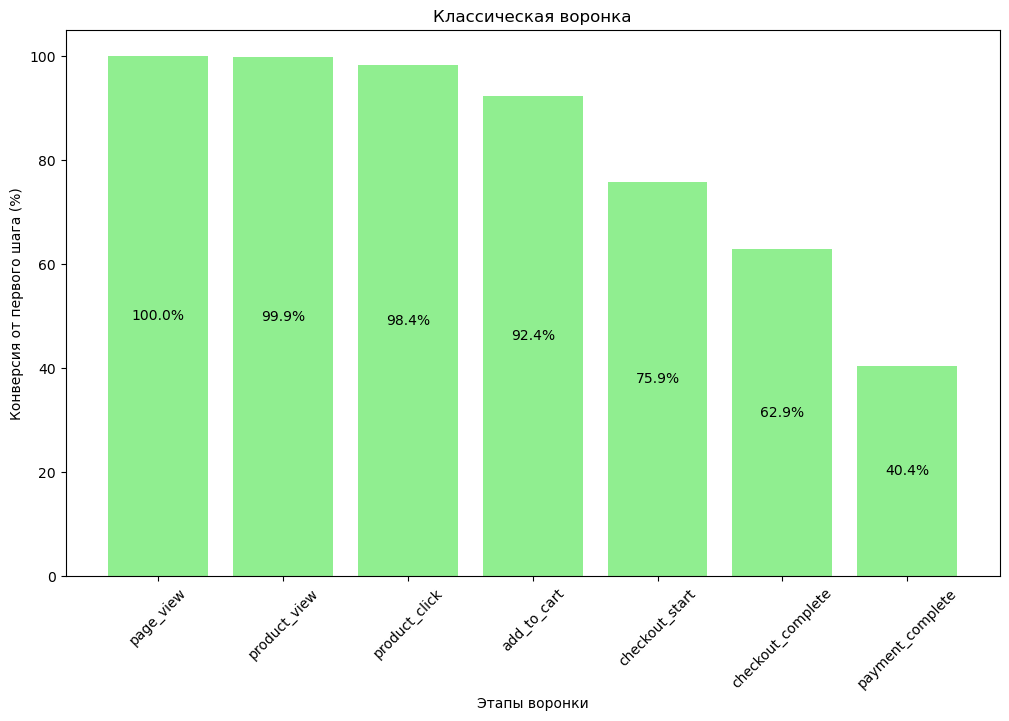

In [48]:
# Cоставим классическую и step-by-step воронки для активных пользователей
# Задаём порядок шагов в воронке
funnel_steps = ['page_view', 'product_view', 'product_click', 'add_to_cart', 'checkout_start', 'checkout_complete', 'payment_complete']

# Фильтруем датасет, оставляя только нужные шаги воронки 
funnel_steps_df = events_full[events_full['event_type'].isin(funnel_steps)]

# Считаем число уникальных пользователей на каждом шаге
funnel_counts = funnel_steps_df.groupby('event_type')['user_id'].nunique().reindex(funnel_steps).reset_index()

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step': funnel_counts['event_type'],
   'users': funnel_counts['user_id']
})

# Считаем классическую конверсию
# Сохраним датасет для подсчета классической конверсии отдельно, чтобы не потерять
classic_funnel_df = funnel_df
classic_funnel_df['classic_conversion'] = (classic_funnel_df['users'] / classic_funnel_df['users'].iloc[0] * 100).round(1)

# Визуализируем данные
plt.figure(figsize=(10, 6))
barchart1 = plt.bar(classic_funnel_df['step'], classic_funnel_df['classic_conversion'], color='lightgreen')
for bar in barchart1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height/2,
             f'{height:.1f}%',
             ha='center', va='center',
             fontsize=10,
             color='black')
plt.tight_layout()
plt.title('Классическая воронка')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
plt.show()

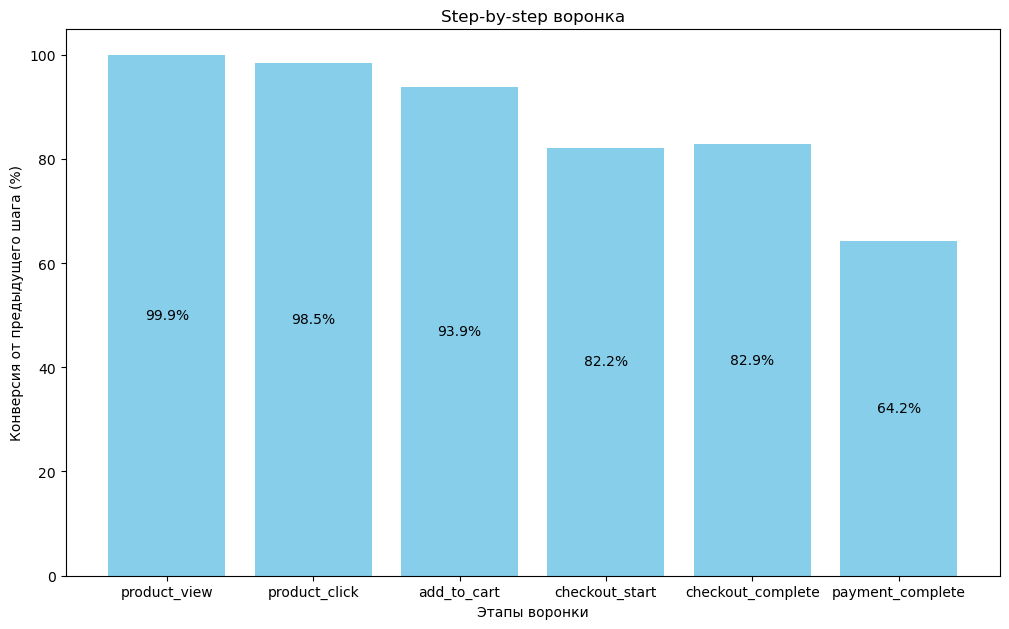

In [49]:
# Считаем step-by-step конверсию
# Создаем отдельный датасет, чтобы не потерять данные
step_funnel_df = funnel_df
step_funnel_df['step_conversion'] = (step_funnel_df['users'] / step_funnel_df['users'].shift(1) * 100).round(1)

# Визуализируем данные
plt.figure(figsize=(10, 6))
barchart2 = plt.bar(step_funnel_df['step'][1:], step_funnel_df['step_conversion'][1:], color='skyblue')
for bar in barchart2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height/2,
             f'{height:.1f}%',
             ha='center', va='center',
             fontsize=10,
             color='black')
plt.tight_layout()
plt.title('Step-by-step воронка')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

В целом маркетплейс имеет достаточно высокую конверсию: 40,4% активных клиентов доходят до внесения оплаты.
Наибольший отток пользователей фиксируется в нижней части воронки - на этапах оформления заказа и его оплате:
* Этап checkout_start: конверсия от первого шага - 75,9%, конверсия от предедущего шага (add_to_cart) - 82,2%
* Этап checkout_complete: конверсия от первого шага - 62,9%, конверсия от предедущего шага (add_to_cart) - 82,9%
* Этап payment_complete (максимальный отток): конверсия от первого шага - 40,4%, конверсия от предедущего шага (checkout_complete) - 64,2%

### Сегментация пользователей

In [50]:
# Подготовим датасет для сегментации пользователей
# Разобьем возраст пользователей на категории
bins = [17, 24, 34, 44, 54, 120]  # Нижняя граница 17, чтобы включить 18
labels = ['18-24', '25-34', '35-44', '45-54', '55+']

users['age_category'] = pd.cut(users['age'], bins=bins, labels=labels, right=True)

# Проверка:
age_distribution = users['age_category'].value_counts().sort_index()
display(age_distribution)
display(users.info())

age_category
18-24     5824
25-34     8339
35-44     8372
45-54     8306
55+      13310
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
 9   first_month        44151 non-null  datetime64[ns]
 10  age_category       44151 non-null  category      
dtypes: category(1), datetime64[ns](4), int64(2), object(4)
memory usage: 3.4+ MB


None

In [51]:
# 1. Создаем агрегированные данные по пользователям
user_data = users[['user_id', 'age_category', 'gender', 'region', 'buyer_segment']].copy()

# 2. Берем для каждого пользователя первое событие с OS/Device
user_first_event = events.sort_values('event_date').groupby('user_id').first()[['os', 'device']].reset_index()

# 3. Объединяем данные пользователей
user_profile = pd.merge(user_data, user_first_event, on='user_id', how='left')

# 4. Присоединяем к заказам
orders_full = pd.merge(orders, user_profile, on='user_id', how='left')

# 6. Финальная проверка
display(orders_full.info(memory_usage='deep'))
display(orders_full.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  datetime64[ns]
 9   order_month    31357 non-null  datetime64[ns]
 10  revenue        31357 non-null  float64       
 11  first_month    31357 non-null  datetime64[ns]
 12  acq_channel    30446 non-null  object        
 13  event_type     31357 non-null  object        
 14  age_category   30446 non-null  category      
 15  gender         3044

None

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,revenue,first_month,acq_channel,event_type,age_category,gender,region,buyer_segment,os,device
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,553.9130,2024-01-01,Google Ads,payment_complete,55+,F,Санкт-Петербург,regular,Android,mobile
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,567.0190,2024-01-01,Google Ads,payment_complete,55+,F,Санкт-Петербург,regular,Android,mobile
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,1089.2090,2024-01-01,Google Ads,payment_complete,55+,F,Санкт-Петербург,regular,Android,mobile
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01,553.9130,2024-01-01,Google Ads,payment_complete,55+,F,Санкт-Петербург,regular,Android,mobile
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01,104.9795,2024-01-01,Google Ads,payment_complete,55+,F,Санкт-Петербург,regular,Android,mobile


/var/folders/41/h2320zkx06x5b1fljrrp0f8w0000gn/T/ipykernel_81350/841955877.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arppu_age = orders_full.groupby(['age_category','order_month']).agg({
/var/folders/41/h2320zkx06x5b1fljrrp0f8w0000gn/T/ipykernel_81350/841955877.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arppu_age_table = orders_full.groupby('age_category').agg({


,age_category,user_id,revenue,arppu
1,25-34,1644,4.588303e+06,2790.94
0,18-24,1158,2.849339e+06,2460.57
4,55+,2520,6.194656e+06,2458.20
2,35-44,1702,4.064780e+06,2388.24
3,45-54,1630,3.651833e+06,2240.39


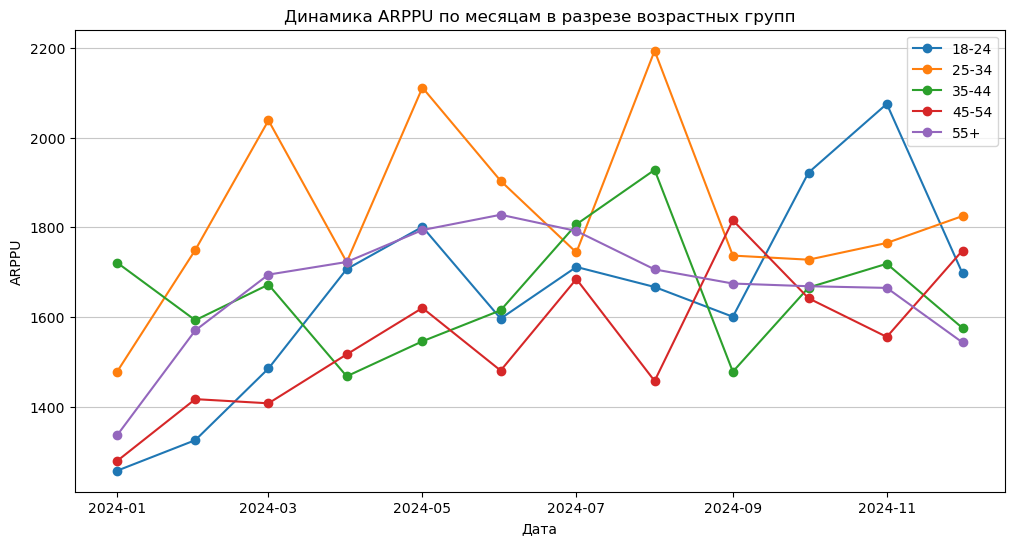

In [52]:
# ARPPU и динамика ARPPU по возрастным категориям
arppu_age = orders_full.groupby(['age_category','order_month']).agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_age['arppu'] = round(arppu_age['revenue'] / arppu_age['user_id'], 2)

arppu_age_table = orders_full.groupby('age_category').agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_age_table['arppu'] = round(arppu_age_table['revenue'] / arppu_age_table['user_id'], 2)

arppu_age_table = arppu_age_table.sort_values('arppu', ascending=False)
display(arppu_age_table)

plt.figure(figsize=(12,6))
for age in arppu_age['age_category'].unique():
    plot_df = arppu_age[arppu_age['age_category'] == age]
    plt.plot(plot_df['order_month'], plot_df['arppu'], marker='o', label=age)
plt.title("Динамика ARPPU по месяцам в разрезе возрастных групп")
plt.xlabel("Дата")
plt.ylabel("ARPPU")
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.show()

* Самая платежеспособная аудитория - молодежь: люди в возрасте 25-34 года (ARPPU - 2790,9) и 18-24 года (ARPPU - 2460,6). В конце года отмечается снижение ARPPU пользователей в группе 25-34 лет.
* Наименее платежеспособная аудитория - люди возраста 45-54 лет (ARPPU - 2240,4).
* Самая многочисленная аудитория - пожилые люди (55+ лет): ARPPU у них средний - 2458,2. В конце года также отмечается снижение ARPPU.

,gender,user_id,revenue,arppu
0,F,4381,1.083445e+07,2473.05
1,M,4273,1.051447e+07,2460.68


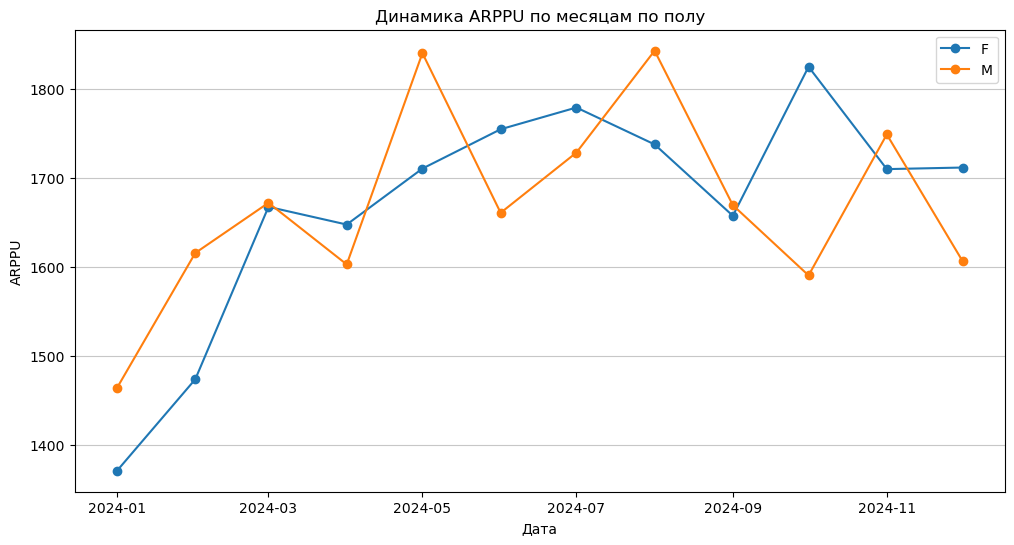

In [53]:
# ARPPU и динамика ARPPU по полу
arppu_genders = orders_full.groupby(['gender','order_month']).agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_genders['arppu'] = round(arppu_genders['revenue'] / arppu_genders['user_id'], 2)

arppu_genders_table = orders_full.groupby('gender').agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_genders_table['arppu'] = round(arppu_genders_table['revenue'] / arppu_genders_table['user_id'], 2)

arppu_genders_table = arppu_genders_table.sort_values('arppu', ascending=False)
display(arppu_genders_table)

plt.figure(figsize=(12,6))
for gender in arppu_genders['gender'].unique():
    plot_df = arppu_genders[arppu_genders['gender'] == gender]
    plt.plot(plot_df['order_month'], plot_df['arppu'], marker='o', label=gender)
plt.title("Динамика ARPPU по месяцам по полу")
plt.xlabel("Дата")
plt.ylabel("ARPPU")
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.show()

* Женцины имеют чуть более высокий ARPPU, чем мужчины (2473,1 против 2460,7).
* Распределение количесива мужчин и женщин примерно одинаковое.
* Начиная с сентября фиксируется небольшое снижение ARPPU среди женщин.

In [54]:
# ARPPU по регионам
arppu_regions_table = orders_full.groupby('region').agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_regions_table['arppu'] = round(arppu_regions_table['revenue'] / arppu_regions_table['user_id'], 2)

arppu_regions_table = arppu_regions_table.sort_values('arppu', ascending=False)
display(arppu_regions_table)

,region,user_id,revenue,arppu
1,Екатеринбург,418,1.143766e+06,2736.28
8,Санкт-Петербург,1317,3.396293e+06,2578.81
2,Краснодар,290,7.288376e+05,2513.23
3,Москва,2200,5.410184e+06,2459.17
4,Московская область,681,1.658614e+06,2435.56
0,Другие регионы,2816,6.837361e+06,2428.04
5,Нижний Новгород,354,8.414220e+05,2376.90
6,Новосибирск,310,7.287291e+05,2350.74
7,Ростов-на-Дону,268,6.037048e+05,2252.63


* Самые платежеспособные пользователи проживают в Екатеринбурге (ARPPU - 2736,3), Санкт-Петербурге (ARPPU - 2578,8) и Краснодаре (ARPPU - 2513,2).
* Наименее платежеспособные и самые малочисленные пользователи - из Ростова-на-Дону (ARPPU - 2252,6, кол-во пользователей - 268)
* Больше всего пользователей из Москвы (2200), Санкт-Петербурга (1317) и других регионов (2816). В Москве и других регионах ARPPU находится в пределах средних значений (2430-2460).
* Меньше всего пользователей из Ростова-на-Дону (268), Краснодара (290), Новосибирска (310) и Нижнего Новгорода (354).

,buyer_segment,user_id,revenue,arppu
3,regular,3716,1.489044e+07,4007.12
0,medium,3692,5.190508e+06,1405.88
2,rare,988,1.046910e+06,1059.63
1,one_time,258,2.210517e+05,856.79


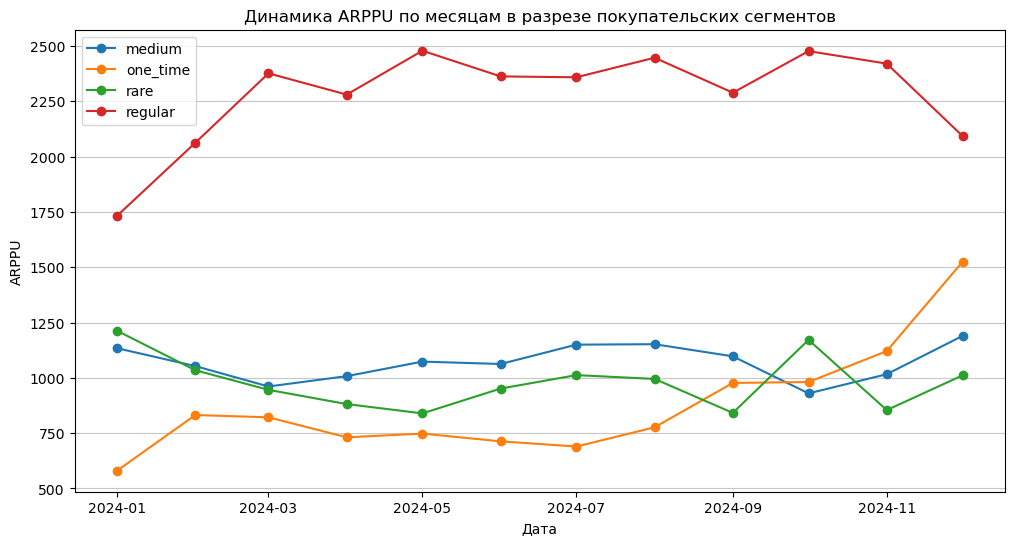

In [55]:
# ARPPU и динамика ARPPU по покупательским сегментам
arppu_segments = orders_full.groupby(['buyer_segment','order_month']).agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_segments['arppu'] = round(arppu_segments['revenue'] / arppu_segments['user_id'], 2)

arppu_segments_table = orders_full.groupby('buyer_segment').agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_segments_table['arppu'] = round(arppu_segments_table['revenue'] / arppu_segments_table['user_id'], 2)

arppu_segments_table = arppu_segments_table.sort_values('arppu', ascending=False)
display(arppu_segments_table)

plt.figure(figsize=(12,6))
for segment in arppu_segments['buyer_segment'].unique():
    plot_df = arppu_segments[arppu_segments['buyer_segment'] == segment]
    plt.plot(plot_df['order_month'], plot_df['arppu'], marker='o', label=segment)
plt.title("Динамика ARPPU по месяцам в разрезе покупательских сегментов")
plt.xlabel("Дата")
plt.ylabel("ARPPU")
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.show()

* Ожидаемо, самый высокий ARPPU у регулярных пользователей (4007,1), а самый низкий - у пользователей, совершивших однократную покупку (856,8).
* У пользователей, делающих покупки со средней периодичностью ARPPU значительно ниже, чем у частых покупателей (1405,9), у пользователей, совершающих редкие покупки, ARPPU еще ниже (1059,6).
* Среди покупателей больше всего регулярных пользователей и тех, кто совершает покупки со средней периодичностью (более 85% от общего числа), меньше всего - с однократной покупкой (3%).

,os,user_id,revenue,arppu
2,iOS,1748,4992151.443,2855.92
3,macOS,1739,4895318.092,2815.02
0,Android,1792,4958230.785,2766.87
1,Windows,1791,4575942.250,2554.96


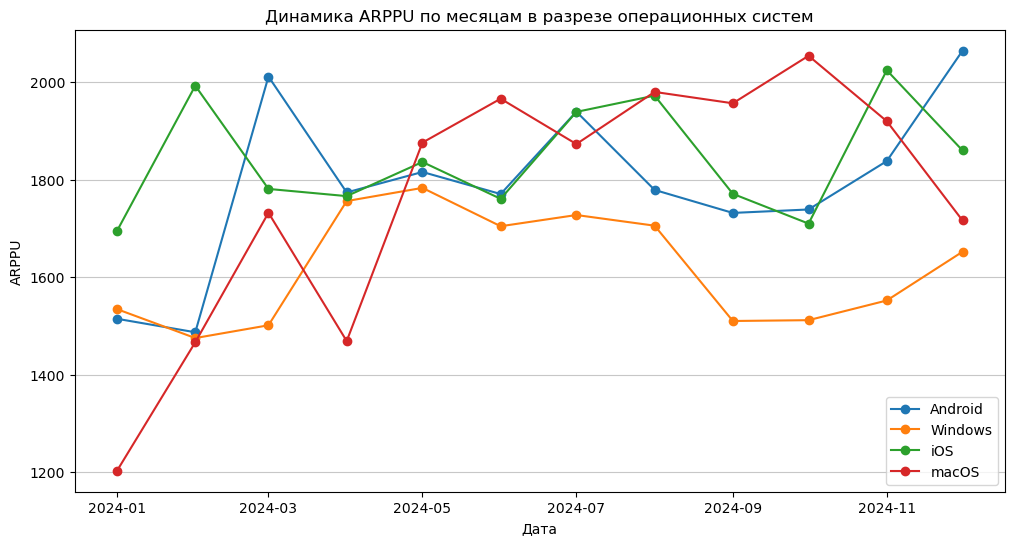

In [56]:
# ARPPU и динамика ARPPU по покупательским сегментам
arppu_os = orders_full.groupby(['os','order_month']).agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_os['arppu'] = round(arppu_os['revenue'] / arppu_os['user_id'], 2)

arppu_os_table = orders_full.groupby('os').agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_os_table['arppu'] = round(arppu_os_table['revenue'] / arppu_os_table['user_id'], 2)

arppu_os_table = arppu_os_table.sort_values('arppu', ascending=False)
display(arppu_os_table)

plt.figure(figsize=(12,6))
for os in arppu_os['os'].unique():
    plot_df = arppu_os[arppu_os['os'] == os]
    plt.plot(plot_df['order_month'], plot_df['arppu'], marker='o', label=os)
plt.title("Динамика ARPPU по месяцам в разрезе операционных систем")
plt.xlabel("Дата")
plt.ylabel("ARPPU")
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.show()

* Самые платежеспособные клиенты - пользователи iOS (ARPPU - 2871,7) и macOS (ARPPU - 2805,8). Наименее платежеспособные - пользователи Windows (ARPPU - 2551,3).
* В конце года наблюдается повышение ARPPU пользователей мобильных ОС (iOS, Android) и Windows, а ARPPU пользователей macOS стал снижаться.
* Распределение пользователей по платформам практически индентичное. 

,device,user_id,revenue,arppu
2,tablet,2291,6.549658e+06,2858.86
1,mobile,2418,6.525681e+06,2698.79
0,desktop,2361,6.346303e+06,2687.97


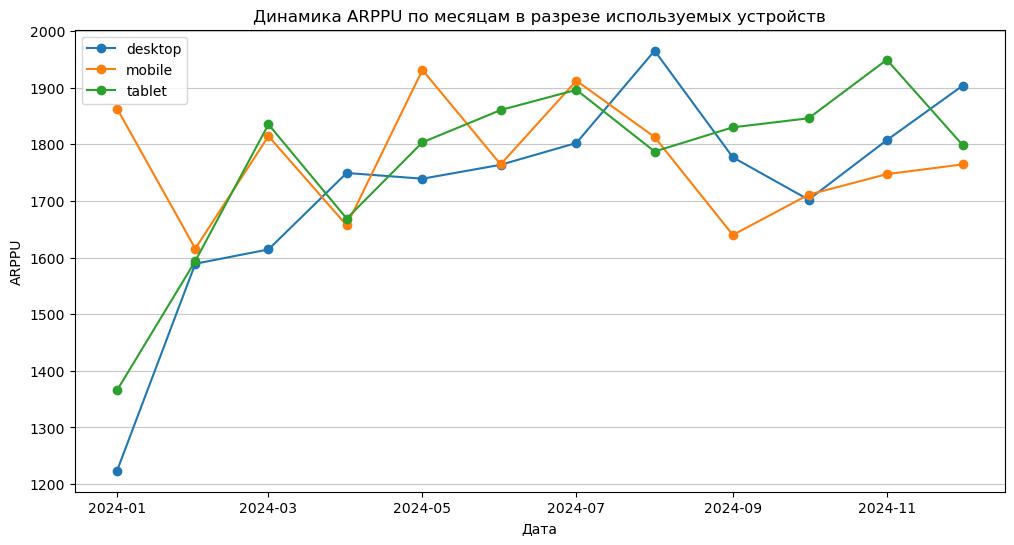

In [57]:
# ARPPU и динамика ARPPU по покупательским сегментам
arppu_devices = orders_full.groupby(['device','order_month']).agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_devices['arppu'] = round(arppu_devices['revenue'] / arppu_devices['user_id'], 2)

arppu_devices_table = orders_full.groupby('device').agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_devices_table['arppu'] = round(arppu_devices_table['revenue'] / arppu_devices_table['user_id'], 2)

arppu_devices_table = arppu_devices_table.sort_values('arppu', ascending=False)
display(arppu_devices_table)

plt.figure(figsize=(12,6))
for device in arppu_devices['device'].unique():
    plot_df = arppu_devices[arppu_devices['device'] == device]
    plt.plot(plot_df['order_month'], plot_df['arppu'], marker='o', label=device)
plt.title("Динамика ARPPU по месяцам в разрезе используемых устройств")
plt.xlabel("Дата")
plt.ylabel("ARPPU")
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.show()

* ARPPU пользователей планшетной версии приложения немного выше, чем у пользователей мобильной и декстопной версии (2858,75 против 2679 - 2696).
* ARPPU мобильных пользователей демонстрирует снижение в конце года.
* Распределение пользователей по версиям приложения примерно одинаковое.

,acq_channel,user_id,revenue,arppu
0,Affiliate,2338,6.735815e+06,2881.02
2,Google Ads,3187,8.236760e+06,2584.49
4,Social Media,1211,3.000255e+06,2477.50
3,SEO,874,1.909935e+06,2185.28
1,Email Marketing,325,5.556987e+05,1709.84
5,TikTok,719,9.104482e+05,1266.27


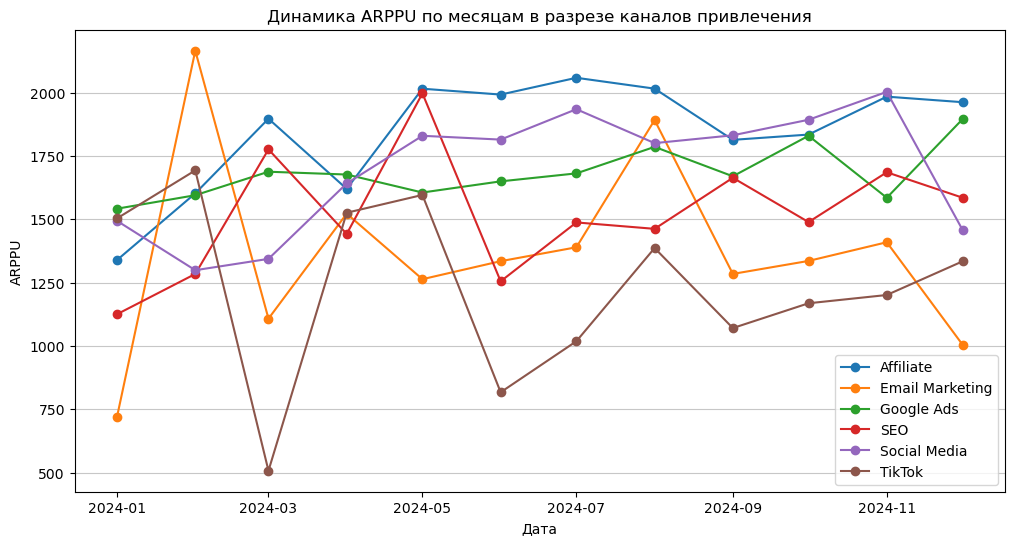

In [58]:
# ARPPU и динамика ARPPU по каналам привлечения
arppu_channels = orders_full.groupby(['acq_channel','order_month']).agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_channels['arppu'] = round(arppu_channels['revenue'] / arppu_channels['user_id'], 2)

arppu_channels_table = orders_full.groupby('acq_channel').agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_channels_table['arppu'] = round(arppu_channels_table['revenue'] / arppu_channels_table['user_id'], 2)

arppu_channels_table = arppu_channels_table.sort_values('arppu', ascending=False)
display(arppu_channels_table)

plt.figure(figsize=(12,6))
for channel in arppu_channels['acq_channel'].unique():
    plot_df = arppu_channels[arppu_channels['acq_channel'] == channel]
    plt.plot(plot_df['order_month'], plot_df['arppu'], marker='o', label=channel)
plt.title("Динамика ARPPU по месяцам в разрезе каналов привлечения")
plt.xlabel("Дата")
plt.ylabel("ARPPU")
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.show()

* Самые платежеспособные пользователи были привлечены через каналы Affiliate (ARPPU - 2881) и Google Ads (ARPPU - 2584,5). Череэ этот канал также пришла большая часть платящей аудитории (64%). Динамика ARPPU по этим на протяжении года оставалась стабильной.
* Самый низкий ARPPU у пользователей, пришедших через TikTok (1266,3) и Email Marketing (1709,9). Платящих пользователей эти каналы привлекли крайне мало - всего суммарно 12%.

In [59]:
# ARPPU по категориям товаров
arppu_categories_table = orders_full.groupby('category_name').agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
arppu_categories_table['arppu'] = round(arppu_categories_table['revenue'] / arppu_categories_table['user_id'], 2)

arppu_categories_table = arppu_categories_table.sort_values('arppu', ascending=False)
display(arppu_categories_table)

,category_name,user_id,revenue,arppu
11,Мебель для дома,514,3.580998e+06,6966.92
2,Бытовая техника,546,2.248933e+06,4118.93
24,Украшения и часы,495,1.718297e+06,3471.31
23,Товары для туризма,498,1.137318e+06,2283.77
18,Спортивный инвентарь,523,1.165361e+06,2228.22
0,Автотовары,561,1.044822e+06,1862.43
8,Инструменты и садовый инвентарь,501,8.123728e+05,1621.50
21,Товары для кухни,637,1.030402e+06,1617.59
3,Декор и освещение,538,7.038036e+05,1308.19
15,Обувь мужская,730,9.424817e+05,1291.07


* Самые прибыльные категории товаров - мебель для дома (ARPPU - 6966,9), бытовая техника (ARPPU - 4118,9) и украшения и часы (ARPPU - 3471,3), что обусловлено высокой розничной стоимостью данных товаров.
* Самый низкий ARPPU - у категории продуктов питания (224,3), средств для ухода (252) и книг и канцтоваров (276,7), что обусловлено низкой розничной стоимостью данных товаров. При этом 30% пользователей покупали продукты питания - это самая популярная категория.

## Выводы по этапу 5

### Анализ эффективности каналов привлечения

Для большинства каналов суммарные затраты на привлечение за год не превысили 2 млн у.е. Большая часть бюджета ушла на каналы TikTok (9,7 млн у.е. или 50% от суммарного бюджета) и Google Ads (4,66 млн у.е. или 24% годового бюджета).

* Затраты на каналы Affiliate, Social Media, SEO, Email Marketing и Direct оставались примерно на одинаковом уровне и не превышали 200 тыс у.е./мес.
* Затраты на канал Google Ads были наиболее высокими в начале года (500-600 у.е./мес.), но в октябре Google Ads прекратил деятельность в РФ.
* В начале года затраты на канал TikTok не превышали 200 у.е./мес., но начиная с июня они начали сильно расти: в последнем квартале на данный канал привлечения тратилось порядка 1,3-1,55 млн у.е./мес.

#### Кол-во регистраций

Выделяемый на различные каналы бюджет прямо проворционально влияет на количество новых привлеченных пользователей.

* При сокращении бюджета на канал Google Ads число привлеченных пользователей начало резко снижаться.
* При увеличиении затрат на канал TikTok количество привлеченных пользователей резко выросло с 350-400 новых пользователей в месяц до 3100-3500.
* Канал Direct, на который тратится минимальная доля бюджета (<1%), за год не привлек ни одного пользователя.

#### LTV

Самых платящих пользователей приносили каналы:
* Affiliate (LTV 590-1700)
* Google Ads (LTV 590-1560)
* Social Media (LTV 370-1190)

Канал TikTok, на который было потрачено около половины годового бюджета, привлекает пользователей с экстремально низким LTV (22-89 у.е.).

#### CAC

* Наиболее дорогими каналами привлечения являются каналы Google Ads (ок. 500 у.е./мес) и TikTok (~435 у.е./мес).
* Самый дешевый канал - SEO (~187 у.е./мес), при этом демонстрирующий средний LTV (370-705 у.е.)

#### ROI

* Самые окупаемые каналы: Affiliate (в среднем ~200-250%, максимум - 443% в мае) и SEO (120-290%). Канал Affiliate демонстрирует тенденцию к снижению конверсии к концу года, однако покалатель остается самым высоким в сравнении с другими каналами.
* Каналы с самой низкой окупаемостью: TikTok (стабильно -80% и ниже на протяжении всего года) Email Marketing (-94 - +88%).
* Канал Google Ads, привлекающих пользователей с высокой платежеспособностью, каждый месяц стабильно окупался в среднем на 50-80%.

#### Конверсия из регистрации в покупку

* Высокая конверсия: каналы Affiliate (в среднем 60-80%) и Google Ads (в среднем 40-55%).
* Средняя конверсия: каналы SEO и Social Media (в среднем 40-50%).
* Низкая конверсия: каналы Email Marketing (5-30%) и TikTok (5% и ниже).

### Анализ воронки
В целом маркетплейс имеет достаточно высокую конверсию: 40,4% активных клиентов доходят до внесения оплаты.
Наибольший отток пользователей фиксируется в нижней части воронки - на этапах оформления заказа и его оплате:
* Этап checkout_start: конверсия от первого шага - 75,9%, конверсия от предедущего шага (add_to_cart) - 82,2%
* Этап checkout_complete: конверсия от первого шага - 62,9%, конверсия от предедущего шага (add_to_cart) - 82,9%
* Этап payment_complete (максимальный отток): конверсия от первого шага - 40,4%, конверсия от предедущего шага (checkout_complete) - 64,2%

### Сегментация платежеспособной аудитории

#### Возраст

* Самая платежеспособная аудитория - молодежь: люди в возрасте 25-34 года (ARPPU - 2790,9) и 18-24 года (ARPPU - 2460,6). В конце года отмечается снижение ARPPU пользователей в группе 25-34 лет.
* Наименее платежеспособная аудитория - люди возраста 45-54 лет (ARPPU - 2240,4).
* Самая многочисленная аудитория - пожилые люди (55+ лет): ARPPU у них средний - 2458,2. В конце года также отмечается снижение ARPPU.

#### Пол

* Женцины имеют чуть более высокий ARPPU, чем мужчины (2473,1 против 2460,7).
* Распределение количесива мужчин и женщин примерно одинаковое.
* Начиная с сентября фиксируется небольшое снижение ARPPU среди женщин.

#### Регион проживания

* Самые платежеспособные пользователи проживают в Екатеринбурге (ARPPU - 2736,3), Санкт-Петербурге (ARPPU - 2578,8) и Краснодаре (ARPPU - 2513,2).
* Наименее платежеспособные и самые малочисленные пользователи - из Ростова-на-Дону (ARPPU - 2252,6, кол-во пользователей - 268)
* Больше всего пользователей из Москвы (2200), Санкт-Петербурга (1317) и других регионов (2816). В Москве и других регионах ARPPU находится в пределах средних значений (2430-2460).
* Меньше всего пользователей из Ростова-на-Дону (268), Краснодара (290), Новосибирска (310) и Нижнего Новгорода (354).

#### Частота покупок

* Ожидаемо, самый высокий ARPPU у регулярных пользователей (4007,1), а самый низкий - у пользователей, совершивших однократную покупку (856,8).
* У пользователей, делающих покупки со средней периодичностью ARPPU значительно ниже, чем у частых покупателей (1405,9), у пользователей, совершающих редкие покупки, ARPPU еще ниже (1059,6).
* Среди покупателей больше всего регулярных пользователей и тех, кто совершает покупки со средней периодичностью (более 85% от общего числа), меньше всего - с однократной покупкой (3%).

#### Операционная система

* Самые платежеспособные клиенты - пользователи iOS (ARPPU - 2871,7) и macOS (ARPPU - 2805,8). Наименее платежеспособные - пользователи Windows (ARPPU - 2551,3).
* В конце года наблюдается повышение ARPPU пользователей мобильных ОС (iOS, Android) и Windows, а ARPPU пользователей macOS стал снижаться.
* Распределение пользователей пл платформам практически индентичное.

#### Тип устройства

* ARPPU пользователей планшетной версии приложения немного выше, чем у пользователей мобильной и декстопной версии (2858,75 против 2679 - 2696).
* ARPPU мобильных пользователей демонстрирует снижение в конце года.
* Распределение пользователей по версиям приложения примерно одинаковое.

#### Каналы привлечения

* Самые платежеспособные пользователи были привлечены через каналы Affiliate (ARPPU - 2881) и Google Ads (ARPPU - 2584,5). Череэ этот канал также пришла большая часть платящей аудитории (64%). Динамика ARPPU по этим на протяжении года оставалась стабильной.
* Самый низкий ARPPU у пользователей, пришедших через TikTok (1266,3) и Email Marketing (1709,9). Платящих пользователей эти каналы привлекли крайне мало - всего суммарно 12%.

#### Категории товаров

* Самые прибыльные категории товаров - мебель для дома (ARPPU - 6966,9), бытовая техника (ARPPU - 4118,9) и украшения и часы (ARPPU - 3471,3), что обусловлено высокой розничной стоимостью данных товаров.
* Самый низкий ARPPU - у категории продуктов питания (224,3), средств для ухода (252) и книг и канцтоваров (276,7), что обусловлено низкой розничной стоимостью данных товаров. При этом 30% пользователей покупали продукты питания - это самая популярная категория.

### Ключевые выводы и рекомендации

1. Маркетинговый бюджет распределен неэффективно. 50% всех годовых затрат ушло на канал TikTok, который показал катастрофически низкую эффективность: несмотря на большое количество привлеченных пользователей, они не являются ЦА маркетплейса и быстро уходят после регистрации: об этом говоряь очень низкий LTV, конверсия в покупку менее 5%, отрицательный ROI (ниже 80%). Следует сильно сократить бюджет или полностью отказаться от данного канала привлечения.

2. Наиболее эффективные каналы привлечения - Affiliate и Google Ads. Они привлекли 64% всех платящих пользователей, демонстрируют стабильно высокий LTV и ROI. Рекомендуется увеличить бюджет на канал Affiliate. Канал Google Ads больше не работает в России.

3. Самое узкое место воронки продаж - этап оформления закза и оплаты. Рекомендуется изучить и оптимизировать дизайн и механику оформления заказов и упростить оплату.

4. Канал привлечения CEO недооценен: он имеет самый низкий САС, а также высокие LTV и ROI. Рекомендуется увеличение бюджета на данный канал.

5. Сегмент «регулярных» покупателей приносит основную прибыль компании, поэтому рекомендовано проводить различные мероприятия для удержания данных пользователей, а также мотивации других пользователей к регулярным покупкам на маркетплейсе (рассылка пушей, повышенные скидки для постоянных покупателей, индивидуальные предложения и пр.)

### Гипотезы для развития продуктов

1. **Перераспределение бюджета из TikTok в SEO и Affiliate**

* **Гипотеза**: Если сократить бюджет TikTok на 80% и перераспределить эти средства в каналы SEO и Affiliate, то при сохранении прежнего уровня затрат повысится количество новых платежеспособных пользователей, LTV и ROI маркетинга. Также возможно повышение конверсии в покупку.
  
* **Какие данные это демонстрируют**: Канал TikTok потребляет 50% бюджета, но генерирует трафик с крайне низким LTV и конверсией (менее 5%). В то же время канал Affiliate имеет лучший LTV и ROI и конверсию в продажу, а канал SEO — самый низкий CAC при хорошей окупаемости и средней конверсии.


2. **Упрощение этапа оплаты**

* **Гипотеза**: Если мы упростить форму оформления заказа и оплаты (например, внедрить оплату в один клик для сохраненных карт, уберать лишние поля, добавить популярные платежные системы), то на последних этапах воронки (оформление заказа, оплата) уровень конверсии вырастет.

* **Какие данные это демонстрируют**: Самая большая потеря пользователей происходит на последних этапах: завершение заказа (CR - 62,9%), оплата (CR - 40,4%).

3. **Программы лояльности для сегмента "Regular"**

* **Гипотеза**: Если внедрить закрытую программу лояльности для сегмента «Regular» (например, повышенные скидки для  постоянных пользователей), повысится их retention, ARPPU и частота покупок. Также станет больше постоянных покупателей и вырастет конверсия в покупку.

* **Какие данные это демонстрируют**: Сегмент «Regular» приносит основную массу выручки и имеет самый высокий ARPPU (4007 у.е.). Потеря даже небольшой части этих клиентов критична.

4. **Стимулирование спроса в дорогих товарных категориях**

* **Гипотеза**: Если предлагать покупателям товары из категории «Продукты» и персональные скидки на товары из высокомаржинальных категорий, повысится их ARPPU и LTV.

* **Какие данные это демонстрируют**: Категории «Мебель», «Техника» и «Украшения и часы» имеют самый высокий ARPPU, что сильно превышает ARPPU массовыx категории вроде продуктов питания. Однако продукты пользователи покупают намного чаще (30% пользователей), и за счет них можно значительно повышать ARPPU.

# Дизайн эксперимента: Бонус на первую покупку для пользователей TikTok
## 1. Контекст и цель эксперимента
- **Бизнес-контекст:** Команда продукта запускает эксперимент, направленный на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку
---
## 2. Формат эксперимента
- **Тип эксперимента:** Сплит-роллинг (rolling split)
- **Канал:** Только пользователи, пришедшие с TikTok
- **Группы:**
    - **Контрольная (A):** пользователи TikTok без бонуса
    - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации
- **Период проведения:** 3 недели (фиксировано)
---
## 3. Ключевые метрики
### Основная метрика
- **Конверсия в первую покупку** — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку
- *Цель:* увеличить конверсию с помощью бонуса
- *Критерий успеха:* статистически значимый рост конверсии в тестовой группе
### Вспомогательные метрики
- **ARPU** (средняя выручка на пользователя TikTok)
- **ARPPU** (средняя выручка на покупателя TikTok)
- **AOV** (средний чек TikTok)
### Барьерная метрика
- **Общая выручка от пользователей TikTok**
---
## 4. Размеры групп и запуск
- **Целевая аудитория:** только пользователи TikTok
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи


### Загрузка и предобработка данных

In [60]:
# Загрузим датасеты
events_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events_AB.csv', parse_dates=['event_date', 'event_week', 'event_month'])
orders_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders_AB.csv', parse_dates=['order_date', 'order_week', 'order_month'])
users_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users_AB.csv', parse_dates=['registration_date', 'cohort_week', 'cohort_month'])
split_users_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_AB_split_users.csv')

In [61]:
display(events_ab.info())
display(events_ab.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831231 entries, 0 to 831230
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      831231 non-null  int64         
 1   user_id       831231 non-null  int64         
 2   event_date    831231 non-null  datetime64[ns]
 3   event_type    831231 non-null  object        
 4   os            831231 non-null  object        
 5   device        831231 non-null  object        
 6   product_name  409054 non-null  object        
 7   event_week    831231 non-null  datetime64[ns]
 8   event_month   831231 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 57.1+ MB


None

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01 15:23:56,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01 15:24:01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01 15:24:10,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01 15:25:10,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01 15:25:46,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


In [62]:
# Проверим категориальные данные на наличие дубликатов
display(events_ab['event_type'].unique())
display(events_ab['os'].unique())
display(events_ab['device'].unique())

array(['page_view', 'product_view', 'product_click', 'add_to_cart',
       'checkout_start', 'checkout_complete', 'user_logout', 'search',
       'category_view', 'filter_apply', 'promo_view', 'wishlist_add',
       'user_login', 'banner_click', 'remove_from_cart'], dtype=object)

array(['iOS', 'Windows', 'macOS', 'Android'], dtype=object)

array(['mobile', 'desktop', 'tablet'], dtype=object)

In [63]:
# Проверим датасет на наличие явных дубликатов
events_ab_duplicates = events_ab.duplicated().sum()
display(f'Выявлено {events_ab_duplicates} явных дубликатов')

# Проверим датасет на наличие неявных дубликатов
events_ab_duplicates2 = events_ab[['user_id', 'event_id']].duplicated().sum()
display(f'Выявлено {events_ab_duplicates2} неявных дубликатов')

'Выявлено 0 явных дубликатов'

'Выявлено 93 неявных дубликатов'

In [64]:
# Удаляем неявные дубликаты
events_ab = events_ab.drop_duplicates(subset=['user_id', 'event_id'],keep='first')

# Проверка
display(events_ab.info())

<class 'pandas.core.frame.DataFrame'>
Index: 831138 entries, 0 to 831230
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      831138 non-null  int64         
 1   user_id       831138 non-null  int64         
 2   event_date    831138 non-null  datetime64[ns]
 3   event_type    831138 non-null  object        
 4   os            831138 non-null  object        
 5   device        831138 non-null  object        
 6   product_name  409012 non-null  object        
 7   event_week    831138 non-null  datetime64[ns]
 8   event_month   831138 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 63.4+ MB


None

In [65]:
# Изучим данные, проверим период эксперимента
user_count = events_ab['user_id'].nunique()
event_count = events_ab['event_id'].nunique()
event_date_min = events_ab['event_date'].min()
event_date_max = events_ab['event_date'].max()

display(f"Кол-во уникальных пользователей в базе событий: {user_count}")
display(f"Кол-во уникальных событий: {event_count}")
display(f"Дата и время первого события: {event_date_min}")
display(f"Дата и время последнего события: {event_date_max}")

'Кол-во уникальных пользователей в базе событий: 23948'

'Кол-во уникальных событий: 813509'

'Дата и время первого события: 2024-01-01 15:23:56'

'Дата и время последнего события: 2025-01-26 23:59:34'

In [66]:
display(orders_ab.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       33280 non-null  int64         
 1   user_id        33280 non-null  int64         
 2   order_date     33280 non-null  object        
 3   product_name   33280 non-null  object        
 4   quantity       33280 non-null  int64         
 5   unit_price     33280 non-null  float64       
 6   total_price    33280 non-null  float64       
 7   category_name  33280 non-null  object        
 8   order_week     33280 non-null  datetime64[ns]
 9   order_month    33280 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 2.5+ MB


None

In [67]:
# Проверим категориальные данные на наличие дубликатов
display(orders_ab['category_name'].unique())

array(['Инструменты и садовый инвентарь', 'Продукты питания',
       'Женская одежда', 'Аксессуары для гаджетов', 'Одежда для спорта',
       'Декор и освещение', 'Детская одежда', 'Детские игрушки',
       'Книги и канцтовары', 'Медицинские товары',
       'Косметика и парфюмерия', 'Товары для туризма',
       'Сумки и аксессуары', 'Автотовары', 'Обувь мужская',
       'Обувь женская', 'Мужская одежда', 'Бытовая техника', 'Зоотовары',
       'Товары для кухни', 'Средства для ухода', 'Мебель для дома',
       'Спортивный инвентарь', 'Товары для новорожденных',
       'Украшения и часы'], dtype=object)

In [68]:
# Проверим датасет на наличие явных дубликатов
orders_ab_duplicates = orders_ab.duplicated().sum()
display(f'Выявлено {orders_ab_duplicates} явных дубликатов')

# Проверим датасет на наличие неявных дубликатов
orders_ab_duplicates2 = orders_ab[['user_id', 'order_id']].duplicated().sum()
display(f'Выявлено {orders_ab_duplicates2} неявных дубликатов')

'Выявлено 0 явных дубликатов'

'Выявлено 0 неявных дубликатов'

In [69]:
# Добавим столбец с выручкой
orders_ab['revenue'] = orders_ab['total_price'] * 0.05

# Проверка
display(orders_ab.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       33280 non-null  int64         
 1   user_id        33280 non-null  int64         
 2   order_date     33280 non-null  object        
 3   product_name   33280 non-null  object        
 4   quantity       33280 non-null  int64         
 5   unit_price     33280 non-null  float64       
 6   total_price    33280 non-null  float64       
 7   category_name  33280 non-null  object        
 8   order_week     33280 non-null  datetime64[ns]
 9   order_month    33280 non-null  datetime64[ns]
 10  revenue        33280 non-null  float64       
dtypes: datetime64[ns](2), float64(3), int64(3), object(3)
memory usage: 2.8+ MB


None

In [70]:
# Изучим данные, проверим период эксперимента, проверим на наличие подозрительных значений
user_count = orders_ab['user_id'].nunique()
order_count = orders_ab['order_id'].nunique()
order_date_min = orders_ab['order_date'].min()
order_date_max = orders_ab['order_date'].max()
quantity_min = orders_ab['quantity'].min()
quantity_max = orders_ab['quantity'].max()
quantity_avg = orders_ab['quantity'].mean()
unit_price_min = orders_ab['unit_price'].min()
unit_price_max = orders_ab['unit_price'].max()
unit_price_avg = orders_ab['unit_price'].mean()
total_price_min = orders_ab['total_price'].min()
total_price_max = orders_ab['total_price'].max()
total_price_avg = orders_ab['total_price'].mean()

display(f"Кол-во уникальных пользователей, совершивших заказы: {user_count}")
display(f"Кол-во уникальных заказов: {order_count}")
display(f"Дата и время совершения первого заказа: {order_date_min}")
display(f"Дата и время совершения последнего заказа: {order_date_max}")
display(f"Минимальное количество одного товара, купленного пользователем в одном заказе: {quantity_min}")
display(f"Максимальное количество одного товара, купленного пользователем в одном заказе: {quantity_max}")
display(f"Среднее количество одного товара, купленного пользователем в одном заказе: {quantity_avg.round(2)}")
display(f"Минимальная стоимость одного товара: {unit_price_min}")
display(f"Максимальная стоимость одного товара: {unit_price_max}")
display(f"Средняя стоимость одного товара: {unit_price_avg.round(2)}")
display(f"Минимальная cумма заказа: {total_price_min}")
display(f"Максимальная сумма заказа: {total_price_max}")
display(f"Средняя сумма одного заказа: {total_price_avg.round(2)}")

'Кол-во уникальных пользователей, совершивших заказы: 9566'

'Кол-во уникальных заказов: 33080'

'Дата и время совершения первого заказа: 2024-01-01 08:03:45.000'

'Дата и время совершения последнего заказа: 2025-01-26 23:07:50'

'Минимальное количество одного товара, купленного пользователем в одном заказе: 1'

...

'Максимальная стоимость одного товара: 63932.38'

'Средняя стоимость одного товара: 7008.82'

'Минимальная cумма заказа: 218.82'

'Максимальная сумма заказа: 191797.14'

'Средняя сумма одного заказа: 14077.69'

In [71]:
display(users_ab.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22196 entries, 0 to 22195
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            22196 non-null  int64         
 1   registration_date  22196 non-null  datetime64[ns]
 2   age                22196 non-null  int64         
 3   gender             22196 non-null  object        
 4   region             22196 non-null  object        
 5   acq_channel        22196 non-null  object        
 6   buyer_segment      22196 non-null  object        
 7   cohort_week        22196 non-null  datetime64[ns]
 8   cohort_month       22196 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 1.5+ MB


None

In [72]:
# Проверим категориальные данные на наличие дубликатов
display(users_ab['gender'].unique())
display(users_ab['region'].unique())
display(users_ab['acq_channel'].unique())
display(users_ab['buyer_segment'].unique())

array(['M', 'F'], dtype=object)

array(['Екатеринбург', 'Санкт-Петербург', 'Москва', 'Другие регионы',
       'Ростов-на-Дону', 'Московская область', 'Нижний Новгород',
       'Новосибирск', 'Краснодар'], dtype=object)

array(['TikTok'], dtype=object)

array(['one_time', 'rare', 'medium', 'regular'], dtype=object)

In [73]:
# Проверим датасет на наличие явных дубликатов
users_ab_duplicates = users_ab.duplicated().sum()
display(f'Выявлено {users_ab_duplicates} явных дубликатов')

# Проверим датасет на наличие неявных дубликатов
users_ab_duplicates2 = users_ab[['user_id']].duplicated().sum()
display(f'Выявлено {users_ab_duplicates2} неявных дубликатов')

'Выявлено 0 явных дубликатов'

'Выявлено 0 неявных дубликатов'

In [74]:
# Изучим данные, проверим на наличие подозрительных значений, проверим наличие дат проведения эксперимента
user_count = users_ab['user_id'].nunique()
reg_date_min = users_ab['registration_date'].min()
reg_date_max = users_ab['registration_date'].max()
age_min = users_ab['age'].min()
age_max = users_ab['age'].max()
age_avg = users_ab['age'].mean()

display(f"Кол-во уникальных пользователей в базе: {user_count}")
display(f"Дата и время первой регистрации: {reg_date_min}")
display(f"Дата и время последней регистрации: {reg_date_max}")
display(f"Минимальный возраст покупателя: {age_min}")
display(f"Максимальный возраст покупателя: {age_max}")
display(f"Средний возраст покупателя: {age_avg.round(2)}")

'Кол-во уникальных пользователей в базе: 22196'

'Дата и время первой регистрации: 2024-01-01 01:13:00'

'Дата и время последней регистрации: 2025-01-26 23:41:00'

'Минимальный возраст покупателя: 18'

'Максимальный возраст покупателя: 70'

'Средний возраст покупателя: 44.1'

In [75]:
display(split_users_ab.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2968 non-null   int64 
 1   group    2968 non-null   object
dtypes: int64(1), object(1)
memory usage: 46.5+ KB


None

In [76]:
# Проверим датасет на наличие явных дубликатов
split_users_ab_duplicates = split_users_ab.duplicated().sum()
display(f'Выявлено {split_users_ab_duplicates} явных дубликатов')

# Кол-во групп
display(split_users_ab['group'].unique())

# Проверим, есть ли пользователи, попавшие в обе группы, и исключим таких
# Считаем кол-во уникальных групп на user_id
flawed_users = split_users_ab.groupby('user_id')['group'].nunique().reset_index()

# Фильтруем клиентов у которых больше 1 группы
flawed_users = flawed_users[flawed_users['group'] > 1]

# Убираем пользователей, попавших в несколько групп
split_users_ab = split_users_ab[~split_users_ab['user_id'].isin(flawed_users['user_id'])]

display(split_users_ab.info())

'Выявлено 0 явных дубликатов'

array(['control', 'treatment'], dtype=object)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2968 non-null   int64 
 1   group    2968 non-null   object
dtypes: int64(1), object(1)
memory usage: 46.5+ KB


None

In [77]:
# Проверяем распределение участников эксперимента по группам
exp_users_count = split_users_ab.groupby('group')['user_id'].nunique().reset_index()
exp_users_total = exp_users_count['user_id'].sum()
exp_users_count['share'] = round(exp_users_count['user_id'] / exp_users_total * 100, 2)
display(exp_users_count)

,group,user_id,share
0,control,1503,50.64
1,treatment,1465,49.36


In [78]:
# Оставляем в датасетах только пользователей, участвовавших в эксперименте, и присоединяем информацию о группах

# Датасет orders_ab
orders_ab = orders_ab[orders_ab['user_id'].isin(split_users_ab['user_id'])]

# Датасет users_ab
users_ab = users_ab[users_ab['user_id'].isin(split_users_ab['user_id'])]

# Объединяем все данные в единый датасет. Датасет events в ходе тестирования гипотез нам не понадобится, поэтому не присовединяем его
ab_df = pd.merge(split_users_ab, users_ab, how='left', on='user_id')

ab_df = pd.merge(ab_df, orders_ab, how='left', on='user_id')
ab_df['order_date'] = pd.to_datetime(ab_df['order_date'])

# Считаем загегистрированных и оплативших заказ пользователей
registered_users = ab_df['user_id'].nunique()
ordered_users = ab_df[~ab_df['order_date'].isna()]['user_id'].nunique()

# Проверка
display(ab_df.info())
display(f"Первая дата регистрации во время эксперимента: {ab_df['registration_date'].min()}")
display(f"Последняя дата регистрации во время эксперимента: {ab_df['registration_date'].max()}")
display(f"Первая дата заказа во время эксперимента: {ab_df['order_date'].min()}")
display(f"Последняя дата заказа во время эксперимента: {ab_df['order_date'].max()}")
display(f"Кол-во зарегистрировавшихся в ходе эксперимента пользователей: {registered_users}")
display(f"Кол-во оплативших заказ в ходе эксперимента пользователей: {ordered_users}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3097 entries, 0 to 3096
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            3097 non-null   int64         
 1   group              3097 non-null   object        
 2   registration_date  3097 non-null   datetime64[ns]
 3   age                3097 non-null   int64         
 4   gender             3097 non-null   object        
 5   region             3097 non-null   object        
 6   acq_channel        3097 non-null   object        
 7   buyer_segment      3097 non-null   object        
 8   cohort_week        3097 non-null   datetime64[ns]
 9   cohort_month       3097 non-null   datetime64[ns]
 10  order_id           255 non-null    float64       
 11  order_date         255 non-null    datetime64[ns]
 12  product_name       255 non-null    object        
 13  quantity           255 non-null    float64       
 14  unit_pri

None

'Первая дата регистрации во время эксперимента: 2025-01-01 00:05:00'

'Последняя дата регистрации во время эксперимента: 2025-01-26 23:41:00'

'Первая дата заказа во время эксперимента: 2025-01-01 11:57:43'

'Последняя дата заказа во время эксперимента: 2025-01-26 20:39:35'

'Кол-во зарегистрировавшихся в ходе эксперимента пользователей: 2968'

'Кол-во оплативших заказ в ходе эксперимента пользователей: 126'

**Вывод:**

В эксперимент попали 2968 новых зарегистрированных пользователей, распределение по группам равномерное (50,6% / 49,4%). Пересечений пользователей между группами не обнаружено.
Важно отметить, что эксперимент длился 26 дней, а не 21 (даты регистрации пользователей: 01.01.2025 - 26.01.2025). Оставим эти данные, чтобы проводить тесты на большем объеме данных.

### Тестирование ключевой метрики: конверсия из регистрации в заказ

Ключевая метрика - **Конверсия в первую покупку** — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку.

Формулируем гипотезы:
* H0: Конверсия в первую покупку в тестовой группе не превышает конверсию в контрольной группе (control >= treatment)
* H0: Конверсия в первую покупку в тестовой группе выше конверсии в контрольной группе (control < treatment)

Для проверки гипотезы используем односторонний Z-тест пропорций.

In [79]:
# Оцениваем конверсии в контрольной и тестовой группах

# Выбираем зарегистрированных пользователей
registration = ab_df.copy()

# Выбираем пользователей, оплативших покупку
order = ab_df[~ab_df['order_date'].isna()].copy()

# Рассчитываем метрики по группам
reg_count = registration.groupby('group')['user_id'].nunique()
order_count = order.groupby('group')['user_id'].nunique()

# Собираем результаты в таблицу
results_df = pd.DataFrame({
   'registration':reg_count,
   'order': order_count
})

# Считаем конверсию
results_df['CR'] = (results_df['order']/results_df['registration'] * 100).round(2)
display(results_df)

,registration,order,CR
group,,,
control,1503,16,1.06
treatment,1465,110,7.51


In [80]:
# Проведем Z-тест пропорций
# Соберем датасет
ztest_df = pd.DataFrame({
    'registrations': reg_count,
    'orders': order_count
}).fillna(0)

# Подсчет конверсии как доля, без перевода в проценты
ztest_df['conversion'] = ztest_df['orders'] / ztest_df['registrations']

# Данные по контрольной группе для Z-теста
control_ord = ztest_df.loc['control', 'orders']
test_ord = ztest_df.loc['treatment', 'orders']

# Данные по тестовой группе для Z-теста
control_reg = ztest_df.loc['control', 'registrations']
test_reg = ztest_df.loc['treatment', 'registrations']

prop_control, prop_test = control_ord/control_reg, test_ord/test_reg

# Проверка предпосылки о достаточном количестве данных
if (prop_control*control_reg > 10)and((1-prop_control)*control_reg > 10)and(prop_test*test_reg > 10)and((1-prop_test)*test_reg > 10): 
    print('Предпосылка о достаточном количестве данных выполняется.')
else:
    print('Предпосылка о достаточном количестве данных не выполняется.')

# Проводим Z-тест
z_stat, p_value = proportions_ztest(count=[control_ord, test_ord], nobs=[control_reg, test_reg], alternative='smaller')

# Собираем таблицу с конверсиями в обеих группах, p-value и абсолютной и относительной разницей
final_results = pd.DataFrame([{
    'Group A': 'control',
    'Group B': 'treatment',
    'p-value': p_value,
    'CR A': ztest_df.loc['control', 'conversion'],
    'CR B': ztest_df.loc['treatment', 'conversion'],
    'Absolute Lift': ztest_df.loc['treatment', 'conversion'] - ztest_df.loc['control', 'conversion'],
    'Relative Lift (%)': round((ztest_df.loc['treatment', 'conversion']- ztest_df.loc['control', 'conversion']) / ztest_df.loc['control', 'conversion'], 4)
}])

# Переводим значения конверсии в проценты
final_results['CR A'] = (final_results['CR A'] * 100).round(2)
final_results['CR B'] = (final_results['CR B'] * 100).round(2)

display(final_results)

Предпосылка о достаточном количестве данных выполняется.


,Group A,Group B,p-value,CR A,CR B,Absolute Lift,Relative Lift (%)
0,control,treatment,1.582453e-18,1.06,7.51,0.06444,6.0533


**Вывод:**

Значение конверсии в заказ в контрольной группе - 1,06%, в тестовой группе - 7,51%. Абсолютный прирост относительно контрольной группы составил 6,44 п.п., относительный - 605,3%. P-value очень близко к нулю и не превышает значение alpha (0.05), поэтому отвергаем нулевую гипотезу и считаем, что введение приветственного бонуса для новых пользователей, пришедших из канала TikTok, оказывает статистически значимое влияние на конверсию в заказ.

### Тестирование вспомогательных метрик

#### Первая вспомогательная метрика - ARPU (средняя выручка на пользователя TikTok)

Первая вспомогательная метрика - **ARPU**.

Формулируем гипотезы:
* H0: ARPU в тестовой группе не превышает ARPU в контрольной группе (control >= treatment)
* H1: ARPU в тестовой группе выше ARPU в контрольной группе (control < treatment)

Так как данные распределены крайне неравномерно (см. гистограмму ниже), для проверки гипотезы используем односторонний тест Манна-Уитни.

'Средняя выручка на пользователя: 71.15852307951482, медиана: 0.0, стандартное отклонение: 543.1989184978225'

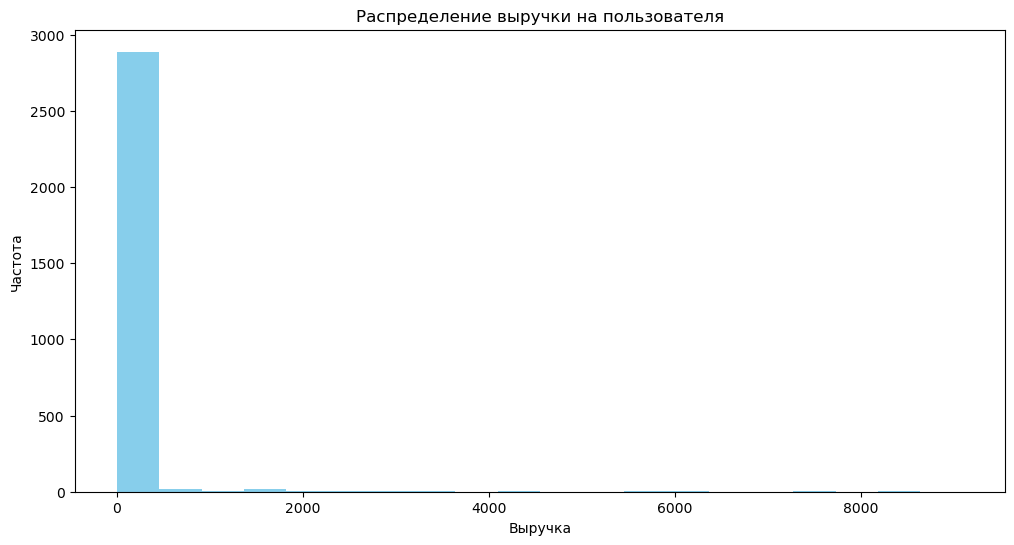

In [81]:
# Проверим распределение средней выручки на пользователя
ab_df['revenue'] = ab_df['revenue'].fillna(0)
user_revenue_stats = ab_df.groupby('user_id')['revenue'].sum().reset_index()

user_revenue_mean = user_revenue_stats['revenue'].mean()
user_revenue_median = user_revenue_stats['revenue'].median()
user_revenue_std = user_revenue_stats['revenue'].std()

display(f"Средняя выручка на пользователя: {user_revenue_mean}, медиана: {user_revenue_median}, стандартное отклонение: {user_revenue_std}")

plt.figure(figsize=(12,6))
plt.hist(user_revenue_stats['revenue'], bins=20, color='skyblue')
plt.title("Распределение выручки на пользователя")
plt.xlabel("Выручка")
plt.ylabel("Частота")
plt.show()

In [82]:
# Считаем ARPU в контрольной и тестовой группах
arpu = ab_df.groupby(['group', 'user_id'])['revenue'].sum().reset_index()
arpu_means = arpu.groupby('group')['revenue'].mean().reset_index()
display(arpu_means)

,group,revenue
0,control,12.587255
1,treatment,131.249045


In [83]:
# Считаем ARPU в контрольной и тестовой группах, а также рассчитаем абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной и p-value
arpu_control = arpu[arpu['group'] == 'control']
arpu_test = arpu[arpu['group'] == 'treatment']

# Проводим тест Манна-Уитни, альфа - 0,05
t_stat, p_value = mannwhitneyu(arpu_control['revenue'], arpu_test['revenue'], alternative='less')
final_results = pd.DataFrame([{
    'Group A': 'control',
    'Group B': 'treatment',
    'p-value': p_value,
    'Mean A': arpu_control['revenue'].mean(),
    'Mean B': arpu_test['revenue'].mean(),
    'Absolute Lift': arpu_test['revenue'].mean() - arpu_control['revenue'].mean(),
    'Relative Lift (%)': round((arpu_test['revenue'].mean() - arpu_control['revenue'].mean())/arpu_control['revenue'].mean(),4)
}])

# Создаём DataFrame из результатов
display(final_results.head())

,Group A,Group B,p-value,Mean A,Mean B,Absolute Lift,Relative Lift (%)
0,control,treatment,1.766304e-18,12.587255,131.249045,118.66179,9.4271


**Вывод:**

Значение ARPU в контрольной группе - 12,59, в тестовой группе - 131,25. Абсолютный прирост относительно контрольной группы составил 118,67 у.е., относительный - 942,7%. P-value очень близко к нулю и не превышает значение alpha (0.05), поэтому отвергаем нулевую гипотезу и считаем, что введение приветственного бонуса для новых пользователей, пришедших из канала TikTok, оказывает статистически значимое влияние на ARPU.

#### Вторая вспомогательная метрика - ARPPU (средняя выручка на покупателя TikTok)

Первая вспомогательная метрика - **ARPPU**.

Формулируем гипотезы:
* H0: ARPPU в тестовой группе не превышает ARPPU в контрольной группе (control >= treatment)
* H1: ARPPU в тестовой группе выше ARPPU в контрольной группе (control < treatment)

Так как данные крайне неравномерно (см. гистограмму ниже), для проверки гипотезы используем односторонний тест Манна-Уитни.

'Средния выручка на платящего пользователя: 1676.1785436507937, медиана: 861.8490000000002, стандартное отклонение: 2071.6760998335512'

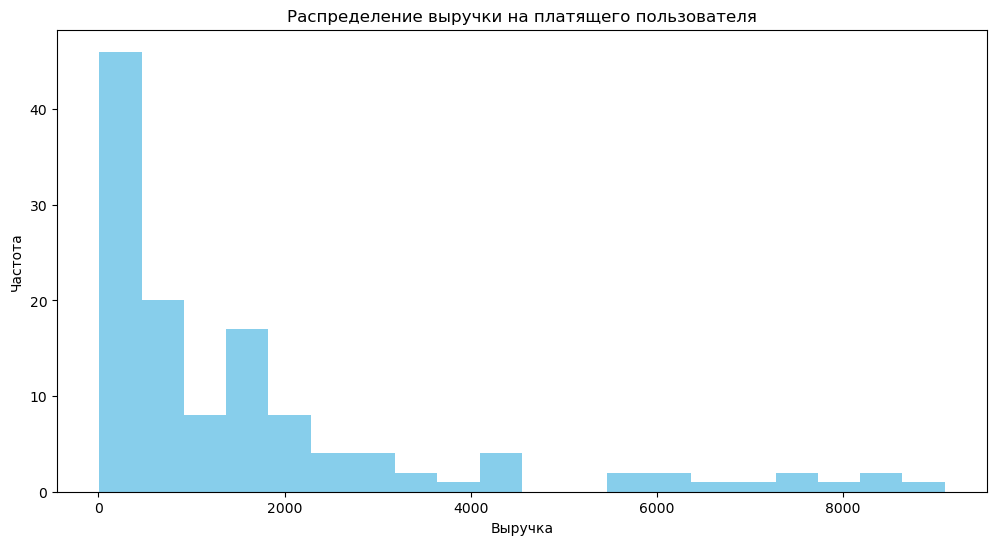

In [84]:
# Проверим распределение средней выручки на платящего пользователя
paying_user_revenue_df = ab_df[ab_df['revenue'] > 0].copy()
paying_user_revenue_stats = paying_user_revenue_df.groupby('user_id')['revenue'].sum().reset_index()

paying_user_revenue_mean =paying_user_revenue_stats['revenue'].mean()
paying_user_revenue_median = paying_user_revenue_stats['revenue'].median()
paying_user_revenue_std = paying_user_revenue_stats['revenue'].std()

display(f"Средния выручка на платящего пользователя: {paying_user_revenue_mean}, медиана: {paying_user_revenue_median}, стандартное отклонение: {paying_user_revenue_std}")

plt.figure(figsize=(12,6))
plt.hist(paying_user_revenue_stats['revenue'], bins=20, color='skyblue')
plt.title("Распределение выручки на платящего пользователя")
plt.xlabel("Выручка")
plt.ylabel("Частота")
plt.show()

In [85]:
# Считаем ARPPU в контрольной и тестовой группах
arppu = paying_user_revenue_df.groupby(['group', 'user_id'])['revenue'].sum().reset_index()
arppu_means = arppu.groupby('group')['revenue'].mean().reset_index()
display(arppu_means)

,group,revenue
0,control,1182.415313
1,treatment,1747.998650


In [86]:
# Считаем ARPPU в контрольной и тестовой группах, а также рассчитаем абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной и p-value
arppu_control = arppu[arppu['group'] == 'control']
arppu_test = arppu[arppu['group'] == 'treatment']

# Проводим тест Манна-Уитни, альфа - 0,05
t_stat, p_value = mannwhitneyu(arppu_control['revenue'], arppu_test['revenue'], alternative='less')
final_results = pd.DataFrame([{
    'Group A': 'control',
    'Group B': 'treatment',
    'p-value': p_value,
    'Mean A': arppu_control['revenue'].mean(),
    'Mean B': arppu_test['revenue'].mean(),
    'Absolute Lift': arppu_test['revenue'].mean() - arppu_control['revenue'].mean(),
    'Relative Lift (%)': round((arppu_test['revenue'].mean() - arppu_control['revenue'].mean())/arppu_control['revenue'].mean(),4)
}])

# Создаём DataFrame из результатов
display(final_results.head())

,Group A,Group B,p-value,Mean A,Mean B,Absolute Lift,Relative Lift (%)
0,control,treatment,0.689552,1182.415313,1747.99865,565.583337,0.4783


**Вывод:**

Значение ARPPU в контрольной группе - 1182,42, в тестовой группе - 1747,99. Абсолютный прирост относительно контрольной группы составил 565,58 у.е., относительный - 47,8%. P-value = 0,69 и превышает значение alpha (0.05), поэтому НЕ отвергаем нулевую гипотезу и считаем, что введение приветственного бонуса для новых пользователей, пришедших из канала TikTok, НЕ оказывает статистически значимое влияние на ARPPU.

#### Третья вспомогательная метрика - AOV (средний чек TikTok)

Третья вспомогательная метрика - **AOV**.

Формулируем гипотезы:
* H0: AOV в тестовой группе не превышает AOV в контрольной группе (control >= treatment)
* H1: AOV в тестовой группе выше AOV в контрольной группе (control < treatment)

Так как данные распределены неравномерно (см. гистограмму ниже), для проверки гипотезы используем односторонний тест Манна-Уитни.

'Средняя сумма чека: 828.2293980392158, медиана: 408.56500000000005, стандартное отклонение: 1100.2900388159005'

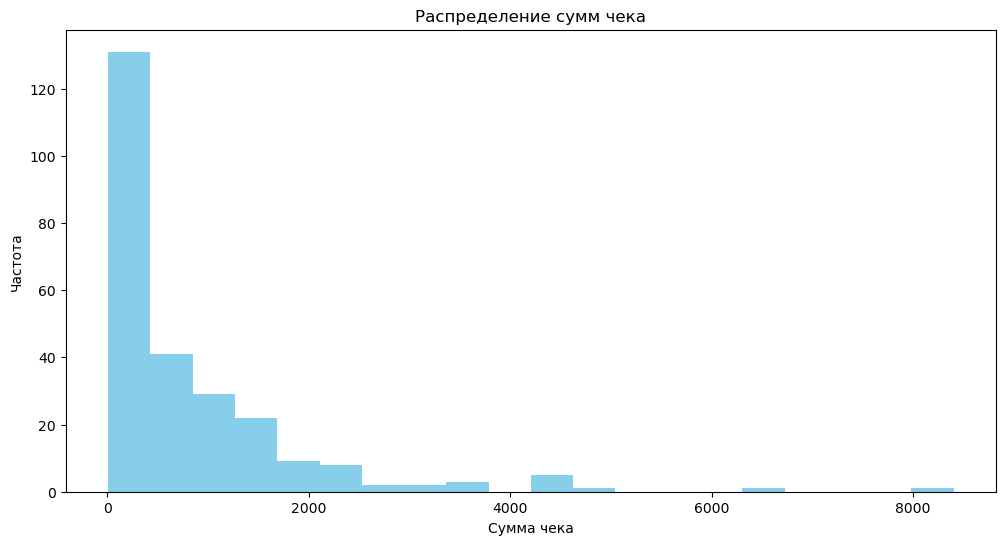

In [87]:
# Проверим распределение суммы чеков
order_rev_df = ab_df[ab_df['revenue'] > 0].copy()
order_rev_stats = order_rev_df.groupby('order_id')['revenue'].sum().reset_index()

order_rev_mean = order_rev_stats['revenue'].mean()
order_rev_median = order_rev_stats['revenue'].median()
order_rev_std = order_rev_stats['revenue'].std()

display(f"Средняя сумма чека: {order_rev_mean}, медиана: {order_rev_median}, стандартное отклонение: {order_rev_std}")

plt.figure(figsize=(12,6))
plt.hist(order_rev_stats['revenue'], bins=20, color='skyblue')
plt.title("Распределение сумм чека")
plt.xlabel("Сумма чека")
plt.ylabel("Частота")
plt.show()

In [88]:
# Считаем AOV в контрольной и тестовой группах
aov = order_rev_df.groupby(['group', 'order_id'])['revenue'].sum().reset_index()
aov_means = aov.groupby('group')['revenue'].mean().reset_index()
display(aov_means)

,group,revenue
0,control,788.276875
1,treatment,832.380310


In [89]:
# Считаем AOV в контрольной и тестовой группах, а также рассчитаем абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной и p-value
aov_control = aov[aov['group'] == 'control']
aov_test = aov[aov['group'] == 'treatment']

# Проводим тест Манна-Уитни, альфа - 0,05
t_stat, p_value = mannwhitneyu(aov_control['revenue'], aov_test['revenue'], alternative='less')
final_results = pd.DataFrame([{
    'Group A': 'control',
    'Group B': 'treatment',
    'p-value': p_value,
    'Mean A': aov_control['revenue'].mean(),
    'Mean B': aov_test['revenue'].mean(),
    'Absolute Lift': aov_test['revenue'].mean() - aov_control['revenue'].mean(),
    'Relative Lift (%)': round((aov_test['revenue'].mean() - aov_control['revenue'].mean())/aov_control['revenue'].mean(),4)
}])

# Создаём DataFrame из результатов
display(final_results.head())

,Group A,Group B,p-value,Mean A,Mean B,Absolute Lift,Relative Lift (%)
0,control,treatment,0.864782,788.276875,832.38031,44.103435,0.0559


**Вывод:**

Значение AOV в контрольной группе - 788,28, в тестовой группе - 832,38. Абсолютный прирост относительно контрольной группы составил 44,1 у.е., относительный - 5,6%. P-value = 0,86 и превышает значение alpha (0.05), поэтому НЕ отвергаем нулевую гипотезу и считаем, что введение приветственного бонуса для новых пользователей, пришедших из канала TikTok, НЕ оказывает статистически значимое влияние на средний чек.

### Барьерная метрика - Общая выручка от пользователей TikTok

Барьерная метрика - **общая выручка от пользователей TikTok**.

Формулируем гипотезы:
* H0: общая выручка в тестовой группе не превышает общую выручку в контрольной группе (control >= treatment)
* H1: общая выручка в тестовой группе выше общей выручка в контрольной группе (control < treatment)

Так как данные распределены неравномерно (см. гистограмму ниже), для проверки гипотезы используем односторонний тест Манна-Уитни.

'Средняя выручка: 828.2293980392158, медиана: 408.56500000000005, стандартное отклонение: 1100.2900388159005'

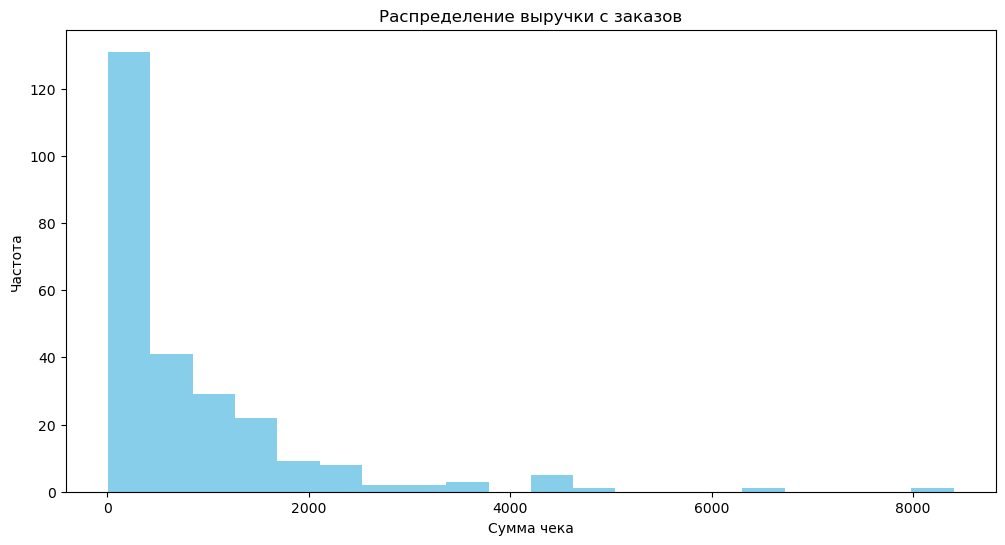

In [90]:
# Проверим распределение суммы чеков
rev_df = ab_df[ab_df['revenue'] > 0].copy()

rev_mean = rev_df['revenue'].mean()
rev_median = rev_df['revenue'].median()
rev_std = rev_df['revenue'].std()

display(f"Средняя выручка: {rev_mean}, медиана: {rev_median}, стандартное отклонение: {rev_std}")

plt.figure(figsize=(12,6))
plt.hist(rev_df['revenue'], bins=20, color='skyblue')
plt.title("Распределение выручки с заказов")
plt.xlabel("Сумма чека")
plt.ylabel("Частота")
plt.show()

In [91]:
# Считаем общую выручку в контрольной и тестовой группах
revenue_stats = rev_df.groupby('group')['revenue'].sum().reset_index()
user_revenue = rev_df.groupby('group')['revenue'].sum().reset_index()
display(revenue_stats)

,group,revenue
0,control,18918.6450
1,treatment,192279.8515


In [92]:
# Считаем общую выручку в контрольной и тестовой группах, а также рассчитаем абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной и p-value
revenue_control = user_revenue[user_revenue['group'] == 'control']
revenue_test = user_revenue[user_revenue['group'] == 'treatment']

# Проводим тест Манна-Уитни, альфа - 0,05
t_stat, p_value = mannwhitneyu(revenue_control['revenue'], revenue_test['revenue'], alternative='less')
final_results = pd.DataFrame([{
    'Group A': 'control',
    'Group B': 'treatment',
    'p-value': p_value,
    'Total A': revenue_control['revenue'].sum(),
    'Total B': revenue_test['revenue'].sum(),
    'Absolute Lift': revenue_test['revenue'].sum() - revenue_control['revenue'].sum(),
    'Relative Lift (%)': round((revenue_test['revenue'].sum() - revenue_control['revenue'].sum())/revenue_control['revenue'].sum(),4)
}])

# Создаём DataFrame из результатов
display(final_results.head())

,Group A,Group B,p-value,Total A,Total B,Absolute Lift,Relative Lift (%)
0,control,treatment,0.5,18918.645,192279.8515,173361.2065,9.1635


**Вывод:**

Значение общей выручки в контрольной группе - 18918,6, в тестовой группе - 173361,2. Абсолютный прирост относительно контрольной группы составил 173361,2 у.е., относительный - 916,4%. P-value = 0,5 и превышает значение alpha (0.05), поэтому НЕ отвергаем нулевую гипотезу и считаем, что введение приветственного бонуса для новых пользователей, пришедших из канала TikTok, НЕ оказывает статистически значимое влияние на общую выручку.

## Выводы по этапу 7

В результате проведения тестирования получены следующие результаты:

| Метрика | Контроль (A) | Тест (B) | Абсолютный рост | Относительный рост | p-value | Стат. значимость |
|---------|--------------|----------|-----------------|---------------------|---------|------------------|
| **Конверсия в покупку** | 1.06% | 7.51% | +6.44 п.п. | **+605%** | **<0.001** |  **Значимо** |
| **ARPU** (ср. выручка на пользователя) | 12.6 у.е. | 131.2 у.е. | +118.6 у.е. | **+943%** | **<0.001** |  **Значимо** |
| **ARPPU** (ср. выручка на покупателя) | 1 182 у.е. | 1 748 у.е. | +566 у.е. | +48% | 0.69 | Не значимо |
| **AOV** (средний чек) | 788 у.е. | 832 у.е. | +44 у.е. | +5.6% | 0.86 | Не значимо |
| **Общая выручка** | 18 919 у.е. | 192 280 у.е. | +173 361 у.е. | **+916%** | 0.5 | Не значимо |


1. Выводы:

* Эксперимент можно считать успешным. Внедрение приветственного бонуса для клиентов, привлеченных через канал TikTok увеличил конверсию (ключевая метрика) в 6,4 раза (с 1% до 7,5%) и среднюю выручку с пользователя (ARPU). Это большой успех для канала, который раньше считался убыточным.
* Вспомогательные метрики ARPPU и общая выручка продемонстрировали большой рост, однако результаты теста говорят о том, что разница незначительна. Вероятнее всего, это произошло по причине большой разницы размеров контрольной и тестовой группах (пользователей, совершивших заказ в контрольной группе - 16, в тестовой - 110). В любом случае, кратный рост вспомогательных и барьерной метрик в тестовой группе очевиден.

2. Рекомендации:

* Внедрить бонус для всех новых пользователей из TikTok. Инструмент доказал свою эффективность мотивации холодной аудитории к совершению покупок.

* Мониторить долю «охотников на бонусы». После внедрения приветственного бонуса важно следить за метриками удержания этих пользователей (retention, конверсия во вторую покупку). Высок риск, что привлеченные пользователи уйдут сразу после активации бонуса. Если retention этих пользователей окажется низким, рекомендуется изменить условия бонуса или продумать действия, направленные на повышение мотивации к повторному заказу (например, начисление бонусов с покупки, которые можно потратить только при следующем заказе).